# 🎧 Music, Brain & Heart — an EEG + ECG study

### How different kinds of music modulate the brain's alpha rhythm and cardiac activity

A **within-subject** study of 14 participants, each recorded under **4 sound conditions** while their **EEG** (brain) and **ECG** (heart) were captured simultaneously with a *Backyard Brains Heart & Brain SpikerBox* (2 channels, 5,000 Hz).

| | |
|---|---|
| **Participants** | Ankit, Atul, Chirag, Daksh, Deepa, Manohar, Nicolas, Omar, Patrik, Pavithra, Piyush, Saiteja, Shalva, Tej (n = 14) |
| **Conditions** | `Silence` · `Meditation` · `Waterfall` · `Stress` (music) |
| **Signals** | Channel 0 = **ECG** · Channel 1 = **EEG** · fs = 5,000 Hz · ~120 s/recording |
| **Markers** | `1` = eyes **closed** · `2` = eyes **open** (alternating) |
| **Recordings** | 55 (13 subjects × 4 conditions + Shalva, who is missing the meditation session) |

**Three guiding questions**

1. 🧠 **Berger effect** — does alpha power (8–12 Hz) rise when the eyes close?
2. 🎼 **Music & relaxation** — which music yields the most alpha (relaxation), and how does heart rate change?
3. 💓 **Brain–heart axis** — does cortical relaxation (alpha) track cardiac slowing?

**What we found, up front**

| | |
|---|---|
| ✓ | **Eyes closed → more alpha** (Berger effect), ≈1.7×, d ≈ 0.8, p < 0.001 — large and highly reliable |
| ✓ | **Brain–heart coupling within subjects**: less alpha ↔ faster heart, ρ ≈ −0.31, p ≈ 0.03 |
| ✗ | **Music type did *not* measurably change alpha** (p ≈ 0.54) or heart rate (p ≈ 0.97) |

This notebook is a **replication**: the same analysis was first run on a 7-subject pilot. The two ✓ effects survived doubling the sample; two apparent music effects from the pilot did not. See §11 for the side-by-side comparison.

> Rigorous methodology: zero-phase filtering (SOS) + mains notch, relative band power, Pan–Tompkins-style beat detection with quality control, non-parametric statistics with effect sizes, and a **leakage-free** classifier (leave-one-subject-out).


## 0 · Setup, style & palette

The whole notebook uses a **single visual system**: a colorblind-validated categorical palette, discrete typography and axes, a faint grid and direct labels. Colors are assigned **by meaning** (silence→blue, meditation→green, waterfall→amber, stress→red) and never recycled.

In [12]:
import os, re, glob, difflib, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
from scipy.io import wavfile
from scipy.signal import (butter, sosfiltfilt, iirnotch, filtfilt, welch,
                          spectrogram, find_peaks, hilbert, decimate)
from scipy import stats
warnings.filterwarnings("ignore")

# ----- paths & constants -----
DATA_DIR = r"/Users/manoharazalki/EEG-ECG-Music/data"
FS        = 5000
ECG_CH, EEG_CH = 0, 1
MAINS_HZ  = 50
MIN_EPOCH = 2          # seconds — epochs shorter than this are dropped (3 of 652 here),
                       # so every Welch PSD shares the same 0.5 Hz frequency grid
BANDS = {"Delta": (1,4), "Theta": (4,8), "Alpha": (8,13), "Beta": (13,30), "Gamma": (30,45)}
STATE = {"1": "closed", "2": "open"}            # 1 = eyes closed, 2 = eyes open
CONDITIONS = ["nomusic", "meditation", "waterfall", "stress"]
COND_EN = {"nomusic":"Silence", "meditation":"Meditation", "waterfall":"Waterfall", "stress":"Stress"}

# ----- colour system (validated, CVD-safe) -----
INK   = "#0b0b0b"; INK2 = "#52514e"; MUTED = "#898781"
GRID  = "#e1e0d9"; AXIS  = "#c3c2b7"; SURF  = "#fcfcfb"
C_COND = {"nomusic":"#2a78d6", "meditation":"#008300", "waterfall":"#eda100", "stress":"#e34948"}
C_STATE = {"closed":"#1c5cab", "open":"#eb6834"}         # closed=deep blue, open=orange
C_ALPHA = "#eb6834"                                       # accent for the alpha band
STATE_EN = {"closed":"Eyes closed", "open":"Eyes open"}

# ----- matplotlib theme -----
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelsize": 11, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "text.color": INK, "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 0.9, "figure.dpi": 110, "savefig.dpi": 130,
    "legend.frameon": False, "legend.fontsize": 10,
})

def style(ax, grid_axis="y"):
    ax.set_axisbelow(True)
    ax.grid(True, axis=grid_axis, color=GRID, linewidth=0.9)
    ax.grid(False, axis="x" if grid_axis=="y" else "y")
    for s in ("top","right"): ax.spines[s].set_visible(False)
    for s in ("left","bottom"):
        ax.spines[s].set_color(AXIS); ax.spines[s].set_linewidth(1.0)
    ax.tick_params(length=0)
    return ax

def cohend(a, b):
    a, b = np.asarray(a,float), np.asarray(b,float)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2)/(na+nb-2))
    return (a.mean()-b.mean())/sp if sp>0 else np.nan

print("Environment ready · numpy", np.__version__, "· matplotlib", mpl.__version__)


Environment ready · numpy 2.4.6 · matplotlib 3.11.1


## 1 · Data loading & manifest

Each `.wav` is paired with its events file. Filenames are inconsistent (`Anit`→`Ankit`, `ChiragMeditationMusic` without hyphens), so matching normalizes the names and falls back to fuzzy matching when needed.

In [13]:
def _norm(p):
    b = os.path.splitext(os.path.basename(p))[0].lower()
    return re.sub(r"[^a-z0-9]", "", re.sub(r"events", "", b))

# Condition patterns tolerate the naming drift in this dataset:
# CamelCase without separators (DakshNoMusic), typos (Meditaation), suffixes (WaterFall-Relax).
COND_PAT = [("nomusic",    r"no\s*music"),
            ("meditation", r"medita+ti?on"),
            ("waterfall",  r"water\s*fall"),
            ("stress",     r"stress")]

def parse_meta(fname):
    base = os.path.splitext(os.path.basename(fname))[0]
    low, best = base.lower(), None
    for cond, pat in COND_PAT:
        m = re.search(pat, low)
        if m and (best is None or m.start() < best[1]):
            best = (cond, m.start())
    if best is None:
        return re.sub(r"[^a-zA-Z]", "", base).capitalize(), "unknown"
    cond, idx = best
    return re.sub(r"[^a-zA-Z]", "", base[:idx]).capitalize(), cond

def build_manifest():
    wavs = sorted(glob.glob(DATA_DIR + "/*.wav"))
    evs  = sorted(glob.glob(DATA_DIR + "/*.txt"))
    evmap = {_norm(e): e for e in evs}; keys = list(evmap)
    rows = []
    for w in wavs:
        k = _norm(w)
        ev = evmap.get(k)
        if ev is None:
            cand = difflib.get_close_matches(k, keys, n=1, cutoff=0.55)
            ev = evmap[cand[0]] if cand else None
        s, c = parse_meta(w)
        rows.append(dict(subject=s, condition=c, wav=w, events=ev))
    df = pd.DataFrame(rows)
    df["condition"] = pd.Categorical(df["condition"], CONDITIONS, ordered=True)
    return df.sort_values(["subject","condition"]).reset_index(drop=True)

def load_events(path):
    d = pd.read_csv(path, comment="#", header=None, names=["marker","time"])
    d["marker"] = d["marker"].astype(str).str.strip()
    d["time"] = d["time"].astype(float)
    return d.sort_values("time").reset_index(drop=True)

def load_signals(wav):
    fs, data = wavfile.read(wav)
    if data.ndim == 1: data = np.column_stack([data, data])
    return fs, data[:,EEG_CH].astype(float), data[:,ECG_CH].astype(float)

manifest = build_manifest()
print(f"{len(manifest)} recordings · {manifest.subject.nunique()} subjects · {manifest.condition.nunique()} conditions")
manifest.pivot_table(index="subject", columns="condition", values="wav",
                     aggfunc="count", observed=False).fillna(0).astype(int)


55 recordings · 14 subjects · 4 conditions


condition,nomusic,meditation,waterfall,stress
subject,,,,
Ankit,1,1,1,1
Atul,1,1,1,1
Chirag,1,1,1,1
Daksh,1,1,1,1
Deepa,1,1,1,1
Manohar,1,1,1,1
Nicolas,1,1,1,1
Omar,1,1,1,1
Patrik,1,1,1,1


## 2 · Preprocessing & feature extraction

**EEG** → DC removal, zero-phase Butterworth SOS band-pass 1–45 Hz (`sosfiltfilt`) and a 50 Hz notch. SOS avoids the numerical blow-up that the `(b,a)` form suffers at 1 Hz with a high sampling rate.

**ECG** → 8–20 Hz band-pass (QRS energy) and **Pan–Tompkins-style** R-peak detection (derivative → square → moving-window integration → adaptive threshold, 0.45 s refractory). We add a **robust autocorrelation heart rate** and a per-recording **quality flag**.

In [14]:
# ---------- EEG ----------
def preprocess_eeg(x, fs=FS):
    x = x - x.mean()
    x = sosfiltfilt(butter(4, [1,45], "band", fs=fs, output="sos"), x)
    b, a = iirnotch(MAINS_HZ, 30, fs)
    return filtfilt(b, a, x)

def bandpowers(x, fs=FS, rel=(1,45)):
    nper = int(min(len(x), fs*2))
    if nper < fs//2:
        return {k: np.nan for k in BANDS} | {k+"_rel": np.nan for k in BANDS}

    f, p = welch(x, fs, nperseg=nper)

    # total power in the 1–45 Hz range
    mask_rel = (f>=rel[0]) & (f<rel[1])
    tot = np.trapezoid(p[mask_rel], x=f[mask_rel])

    out = {}
    for name,(lo,hi) in BANDS.items():
        m = (f>=lo) & (f<hi)
        bp = np.trapezoid(p[m], x=f[m])
        out[name] = bp
        out[name+"_rel"] = bp/tot if tot>0 else np.nan

    return out


def alpha_envelope(x, fs=FS):
    xa = sosfiltfilt(butter(4, [8,13], "band", fs=fs, output="sos"), x)
    env = np.abs(hilbert(xa))
    k = int(0.5*fs)
    return np.convolve(env, np.ones(k)/k, mode="same")

def epochs_from_events(ev, n, fs=FS):
    segs, times = [], list(ev["time"]) + [n/fs]
    for i in range(len(ev)):
        segs.append((ev["time"].iloc[i], times[i+1], STATE.get(ev["marker"].iloc[i], "other")))
    return segs

# ---------- ECG ----------
def detect_rpeaks(ecg, fs=FS, refr=0.45):
    x = ecg - ecg.mean()
    xf = sosfiltfilt(butter(3, [8,20], "band", fs=fs, output="sos"), x)
    mwi = np.convolve(np.gradient(xf)**2, np.ones(int(0.12*fs))/int(0.12*fs), mode="same")
    thr = 0.35*np.median(mwi[mwi > np.percentile(mwi,50)])
    pk,_ = find_peaks(mwi, height=thr, distance=int(refr*fs))
    w, ref = int(0.08*fs), []
    for p in pk:
        a,b = max(0,p-w), min(len(xf),p+w); ref.append(a+np.argmax(np.abs(xf[a:b])))
    return np.array(sorted(set(ref)))

def clean_rr(peaks, fs=FS):
    if len(peaks) < 5: return np.array([])
    rr = np.diff(peaks)/fs*1000
    for _ in range(4):
        med = np.median(rr); keep = (rr>0.7*med)&(rr<1.5*med)&(rr>300)&(rr<1600)
        if keep.all(): break
        rr = rr[keep]
    return rr

def hrv(peaks, fs=FS):
    rr = clean_rr(peaks, fs)
    if len(rr) < 3: return dict(hr=np.nan, rmssd=np.nan, sdnn=np.nan, pnn50=np.nan)
    return dict(hr=60000/np.median(rr), rmssd=np.sqrt(np.mean(np.diff(rr)**2)),
                sdnn=np.std(rr,ddof=1), pnn50=np.mean(np.abs(np.diff(rr))>50)*100)

def hr_autocorr(ecg, fs=FS, hi_bpm=120):
    x = ecg - ecg.mean()
    xf = sosfiltfilt(butter(3, [8,20], "band", fs=fs, output="sos"), x)
    env = np.convolve(xf**2, np.ones(int(0.05*fs))/int(0.05*fs), mode="same")
    q = 20; envd = decimate(env, q, ftype="fir"); fsd = fs/q; envd = envd - envd.mean()
    ac = np.fft.irfft(np.abs(np.fft.rfft(envd, 2*len(envd)))**2)[:len(envd)]
    lo, hi = int(fsd*60/hi_bpm), int(fsd*1.5)
    lag = lo + np.argmax(ac[lo:hi])
    return 60*fsd/lag

print("Preprocessing & feature functions ready.")


Preprocessing & feature functions ready.


### Global computation

We loop over the 28 recordings and build two tables: **`rec`** (one row per recording, cardiac metrics and quality) and **`ep`** (one row per epoch between markers, with band powers and the eyes-closed/open state).

In [15]:
rec_rows, ep_rows = [], []
for _, r in manifest.iterrows():
    fs, eeg_raw, ecg_raw = load_signals(r["wav"])
    eeg = preprocess_eeg(eeg_raw, fs)
    ev  = load_events(r["events"]); n = len(eeg)
    peaks = detect_rpeaks(ecg_raw, fs)
    H = hrv(peaks, fs)
    hr_ac = hr_autocorr(ecg_raw, fs)
    # ECG quality: autocorr HR not railed and consistent with median-RR HR
    good = (hr_ac < 118) and np.isfinite(H["hr"]) and (abs(hr_ac - H["hr"])/hr_ac < 0.15)
    bp_all = bandpowers(eeg, fs)
    rec_rows.append(dict(subject=r["subject"], condition=r["condition"], dur=n/fs,
                         n_markers=len(ev), n_beats=len(peaks), hr=hr_ac,
                         hr_peak=H["hr"], rmssd=H["rmssd"], sdnn=H["sdnn"], pnn50=H["pnn50"],
                         ecg_ok=good, alpha_rel=bp_all["Alpha_rel"]))
    for (s,e,st) in epochs_from_events(ev, n, fs):
        i0,i1 = int(s*fs), int(e*fs); seg = eeg[i0:i1]
        if len(seg) < MIN_EPOCH*fs: continue
        bp = bandpowers(seg, fs)
        pk = peaks[(peaks>=i0)&(peaks<i1)]
        h  = hrv(pk-i0, fs)
        ep_rows.append(dict(subject=r["subject"], condition=r["condition"], state=st,
                            start=s, dur=e-s, hr=h["hr"], rmssd=h["rmssd"], **bp))

rec = pd.DataFrame(rec_rows)
ep  = pd.DataFrame(ep_rows)
for d in (rec, ep):
    d["condition"] = pd.Categorical(d["condition"], CONDITIONS, ordered=True)
ep_state = ep[ep.state.isin(["closed","open"])].copy()
print(f"rec: {len(rec)} recordings · ep: {len(ep)} epochs "
      f"({(ep.state=='closed').sum()} closed / {(ep.state=='open').sum()} open)")
print(f"Good-quality ECG: {rec.ecg_ok.sum()}/{len(rec)} recordings "
      f"(flagged low-quality: {', '.join(sorted(rec[~rec.ecg_ok].subject.unique()))})")


rec: 55 recordings · ep: 649 epochs (328 closed / 321 open)
Good-quality ECG: 50/55 recordings (flagged low-quality: Pavithra, Saiteja)


## 3 · Study at a glance

A **near-complete** design: 13 of the 14 subjects have all 4 conditions (Shalva is missing the meditation session, so 55 recordings rather than 56). Each recording contributes ~12 epochs alternating eyes closed/open. We also flag which recordings pass ECG quality control.

Because repeated-measures tests across conditions require complete cases, Shalva is included in the eyes-closed/open analyses but **dropped from the across-condition tests** — the notebook does this explicitly wherever it matters.

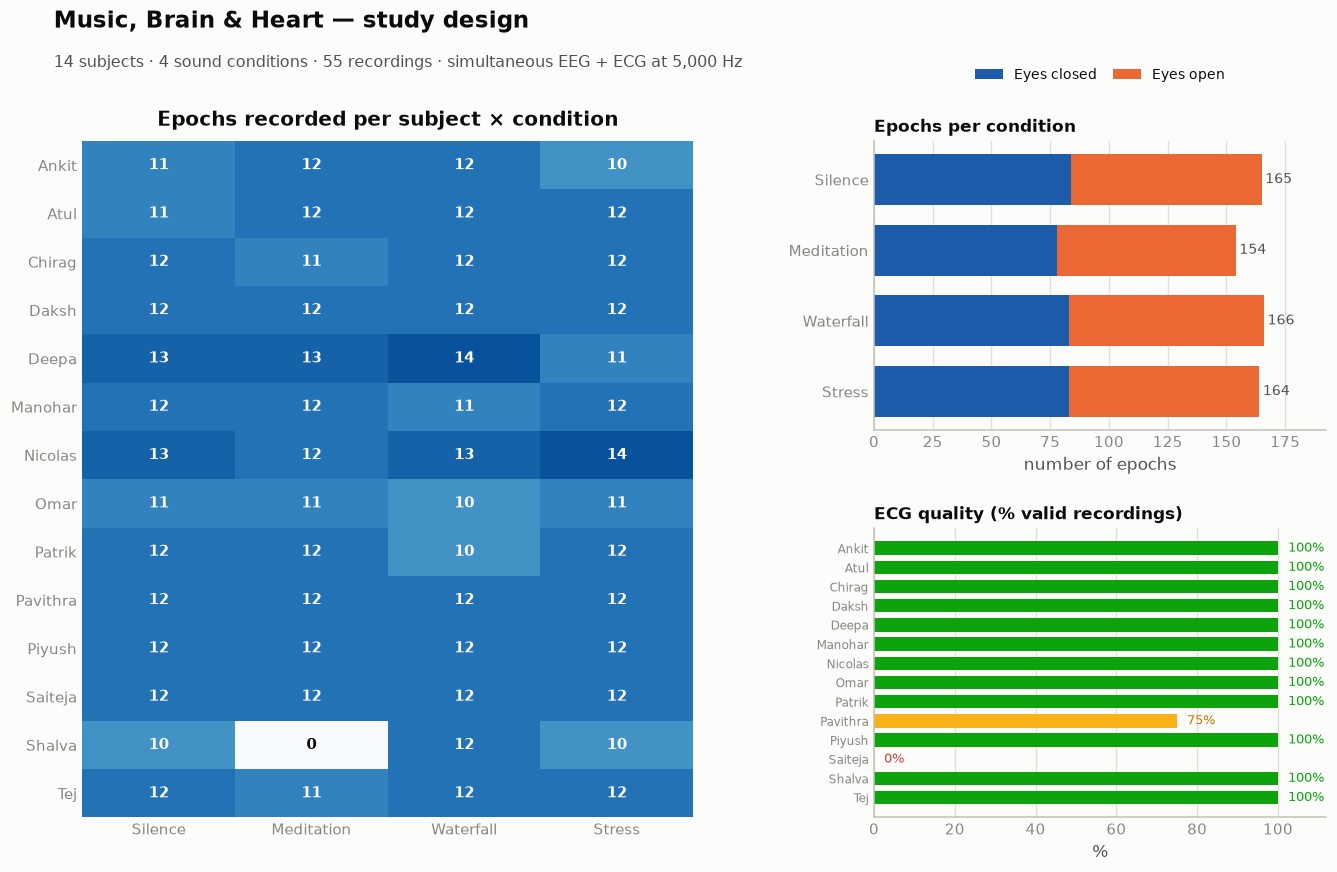

In [16]:
fig = plt.figure(figsize=(13, 8.2))
gs = GridSpec(2, 2, width_ratios=[1.35,1], height_ratios=[1,1], hspace=0.34, wspace=0.34,
              left=0.10, right=0.97, top=0.83, bottom=0.08)
subs = sorted(rec.subject.unique())

axA = fig.add_subplot(gs[:,0])
M = ep_state.pivot_table(index="subject", columns="condition", values="dur",
                         aggfunc="count", observed=False).reindex(subs)[CONDITIONS]
axA.imshow(M.values, cmap="Blues", vmin=0, vmax=M.values.max()*1.15, aspect="auto")
axA.set_xticks(range(4)); axA.set_xticklabels([COND_EN[c] for c in CONDITIONS])
axA.set_yticks(range(len(subs))); axA.set_yticklabels(subs)
for i in range(len(subs)):
    for j in range(4):
        v = M.values[i,j]
        axA.text(j, i, f"{int(v)}", ha="center", va="center",
                 color="white" if v>M.values.max()*0.6 else INK, fontsize=10, fontweight="bold")
axA.set_title("Epochs recorded per subject × condition", pad=10)
axA.grid(False); axA.tick_params(length=0)
for s in axA.spines.values(): s.set_visible(False)

axB = fig.add_subplot(gs[0,1])
cc = ep_state.groupby(["condition","state"], observed=False).size().unstack(fill_value=0)
y = np.arange(4)
axB.barh(y, cc["closed"], height=0.72, color=C_STATE["closed"], label="Eyes closed")
axB.barh(y, cc["open"], height=0.72, left=cc["closed"], color=C_STATE["open"], label="Eyes open")
axB.set_yticks(y); axB.set_yticklabels([COND_EN[c] for c in CONDITIONS])
axB.invert_yaxis(); style(axB, grid_axis="x"); axB.set_xlim(0, cc.sum(axis=1).max()*1.16)
for i,c in enumerate(CONDITIONS):
    tot = cc.loc[c].sum(); axB.text(tot+1.5, i, f"{tot}", va="center", color=INK2, fontsize=9)
axB.set_title("Epochs per condition", fontsize=11, loc="left"); axB.set_xlabel("number of epochs")
axB.legend(loc="lower center", bbox_to_anchor=(0.5, 1.16), ncol=2, fontsize=9, columnspacing=1.2)

axC = fig.add_subplot(gs[1,1])
q = rec.groupby("subject")["ecg_ok"].mean().reindex(subs)
cols = ["#0ca30c" if v==1 else ("#fab219" if v>0 else "#d03b3b") for v in q.values]
axC.barh(range(len(subs)), q.values*100, color=cols, height=0.7)
axC.set_yticks(range(len(subs))); axC.set_yticklabels(subs, fontsize=8)
axC.invert_yaxis(); style(axC, grid_axis="x"); axC.set_xlim(0,112)
for i,v in enumerate(q.values):
    axC.text(max(v*100,0)+2.5, i, f"{v*100:.0f}%", va="center", fontsize=8.5,
             color=("#0ca30c" if v==1 else "#c07a00" if v>0 else "#d03b3b"))
axC.set_title("ECG quality (% valid recordings)", fontsize=11, loc="left"); axC.set_xlabel("%")

fig.suptitle("Music, Brain & Heart — study design", x=0.08, y=0.975, ha="left",
             fontsize=15, fontweight="bold", color=INK)
fig.text(0.08, 0.912, f"{len(subs)} subjects · 4 sound conditions · {len(rec)} recordings · simultaneous EEG + ECG at 5,000 Hz",
         ha="left", fontsize=10.5, color=INK2)
plt.show()


## 4 · Anatomy of a recording

A single session broken into its layers: **raw vs filtered EEG**, the **alpha envelope** (Hilbert transform) that tracks the relaxation rhythm, and the **ECG with detected beats**. Shading marks eyes-closed (blue) and eyes-open (orange) blocks.

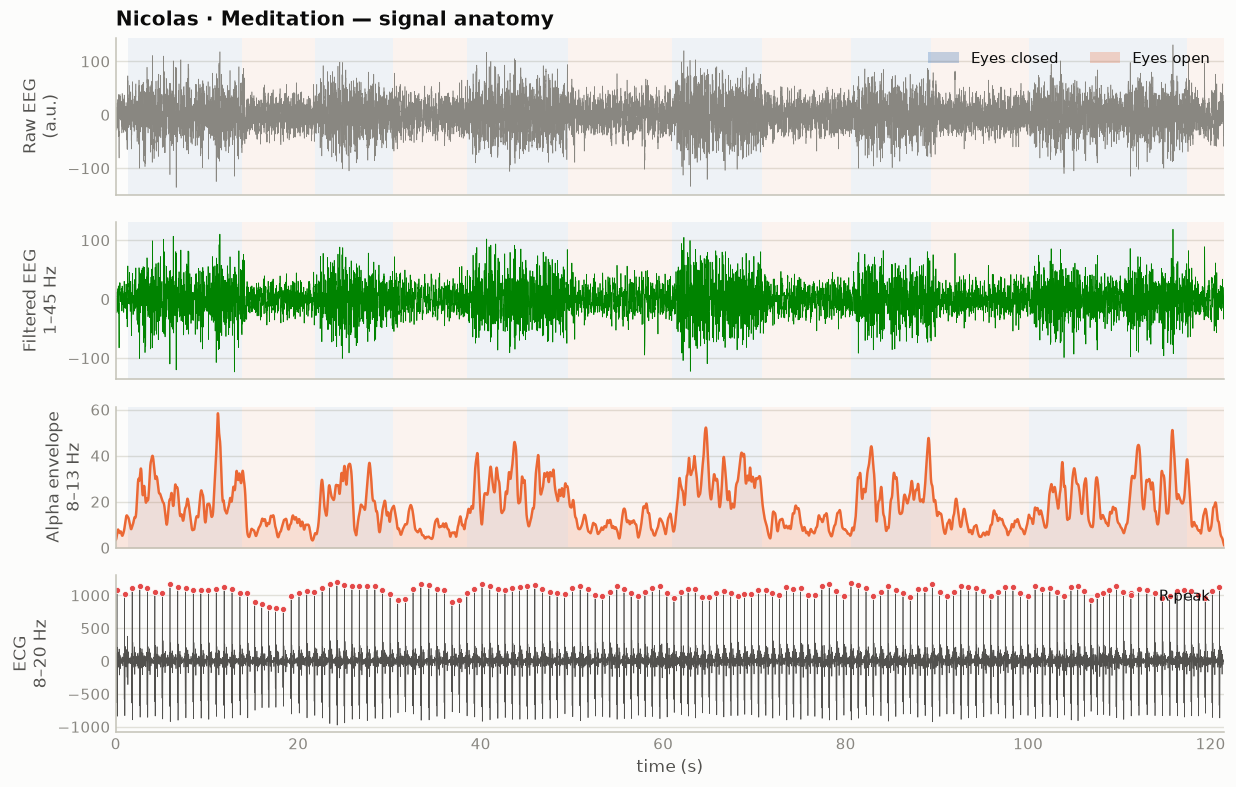

In [17]:
def find_rec(subject, condition):
    row = manifest[(manifest.subject==subject)&(manifest.condition==condition)].iloc[0]
    fs, eeg_raw, ecg_raw = load_signals(row["wav"])
    return fs, eeg_raw, ecg_raw, load_events(row["events"])

SUBJ, COND = "Nicolas", "meditation"
fs, eeg_raw, ecg_raw, ev = find_rec(SUBJ, COND)
eeg = preprocess_eeg(eeg_raw, fs)
ecg = sosfiltfilt(butter(3,[8,20],"band",fs=fs,output="sos"), ecg_raw-ecg_raw.mean())
env = alpha_envelope(eeg, fs); peaks = detect_rpeaks(ecg_raw, fs)
t = np.arange(len(eeg))/fs
segs = epochs_from_events(ev, len(eeg), fs)

fig, axs = plt.subplots(4, 1, figsize=(13, 8.2), sharex=True,
                        gridspec_kw=dict(hspace=0.18, height_ratios=[1,1,0.9,1]))
def shade(ax):
    for (s,e,st) in segs:
        if st in C_STATE: ax.axvspan(s, e, color=C_STATE[st], alpha=0.06, lw=0)

ax=axs[0]; shade(ax); ax.plot(t, eeg_raw-eeg_raw.mean(), color=MUTED, lw=0.4)
ax.set_ylabel("Raw EEG\n(a.u.)"); style(ax,"y")
ax.set_title(f"{SUBJ} · {COND_EN[COND]} — signal anatomy", loc="left", pad=8)
ax=axs[1]; shade(ax); ax.plot(t, eeg, color=C_COND[COND], lw=0.5)
ax.set_ylabel("Filtered EEG\n1–45 Hz"); style(ax,"y")
ax=axs[2]; shade(ax); ax.plot(t, env, color=C_ALPHA, lw=1.6)
ax.fill_between(t, 0, env, color=C_ALPHA, alpha=0.15)
ax.set_ylabel("Alpha envelope\n8–13 Hz"); style(ax,"y"); ax.set_ylim(0,None)
ax=axs[3]; ax.plot(t, ecg, color=INK2, lw=0.45)
ax.plot(peaks/fs, ecg[peaks], "o", ms=4, color=C_COND["stress"], mec="white", mew=0.5, label="R-peak")
ax.set_ylabel("ECG\n8–20 Hz"); ax.set_xlabel("time (s)"); style(ax,"y"); ax.legend(loc="upper right")
ax.set_xlim(0, t[-1])
leg = [Patch(facecolor=C_STATE["closed"], alpha=0.25, label="Eyes closed"),
       Patch(facecolor=C_STATE["open"], alpha=0.25, label="Eyes open")]
axs[0].legend(handles=leg, loc="upper right", ncol=2)
plt.show()


## 5 · The Berger effect

Hans Berger's classic finding (1929): when the **eyes close**, power in the **alpha band (8–12 Hz)** increases. We compare the average spectrum (Welch, 0.5 Hz resolution) of all closed epochs vs open epochs, pooled across all 14 subjects.

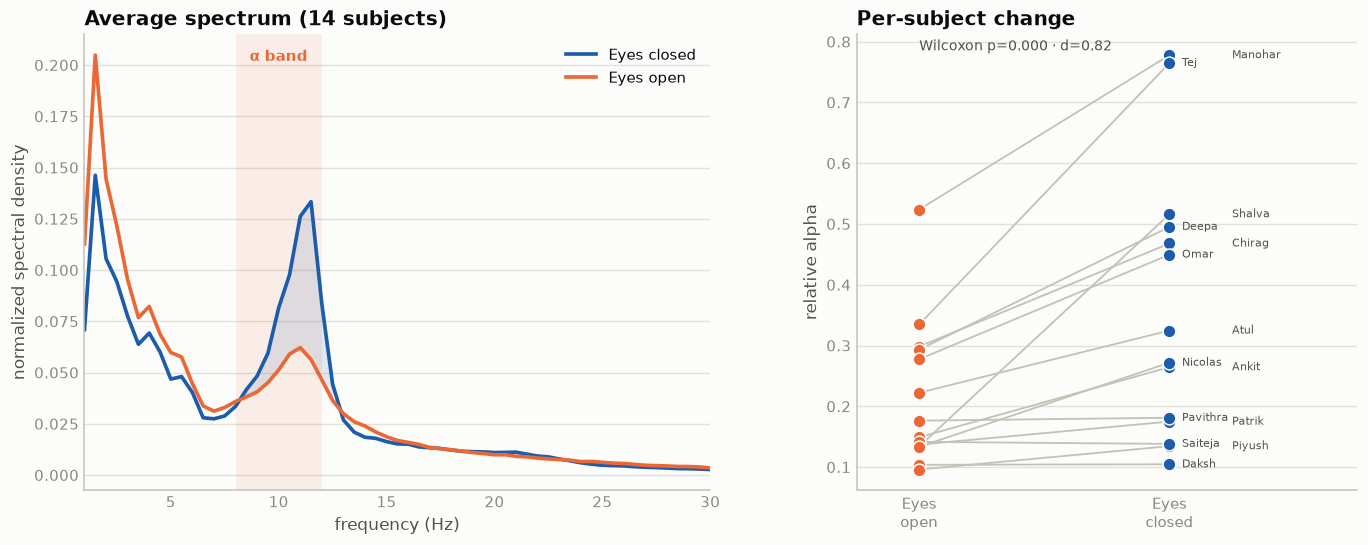

In [18]:
def avg_psd(mask, band=(1,30)):
    acc = None; nf = 0; fsel = None
    for _, r in manifest.iterrows():
        fs, eeg_raw, _ = load_signals(r["wav"])
        eeg = preprocess_eeg(eeg_raw, fs)
        ev = load_events(r["events"])

        for (s,e,st) in epochs_from_events(ev, len(eeg), fs):
            if st != mask:
                continue

            seg = eeg[int(s*fs):int(e*fs)]
            if len(seg) < MIN_EPOCH*fs:
                continue

            f, p = welch(seg, fs, nperseg=int(fs*2))
            sel = (f>=band[0]) & (f<=band[1])
            fsel = f[sel]

            # --- FIX: replace np.trapz with np.trapezoid ---
            mask_rel = (f>=1) & (f<45)
            total_power = np.trapezoid(p[mask_rel], x=f[mask_rel])

            p = p[sel] / total_power

            acc = p if acc is None else acc + p
            nf += 1

    return fsel, acc / nf


fA, pClosed = avg_psd("closed"); _, pOpen = avg_psd("open")

fig = plt.figure(figsize=(13, 5.6))
gs = GridSpec(1, 2, width_ratios=[1.25,1], wspace=0.26, left=0.07, right=0.96, top=0.88, bottom=0.14)
ax = fig.add_subplot(gs[0])
ax.axvspan(8, 12, color=C_ALPHA, alpha=0.10, lw=0)
ax.plot(fA, pClosed, color=C_STATE["closed"], lw=2.4, label="Eyes closed")
ax.plot(fA, pOpen, color=C_STATE["open"], lw=2.4, label="Eyes open")
ax.fill_between(fA, pOpen, pClosed, where=(pClosed>=pOpen), color=C_STATE["closed"], alpha=0.12)
style(ax); ax.set_xlim(1,30); ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("normalized spectral density")
ax.set_title(f"Average spectrum ({ep_state.subject.nunique()} subjects)", loc="left")
ax.text(10, ax.get_ylim()[1]*0.94, "α band", color=C_ALPHA, fontweight="bold", ha="center", fontsize=10)
ax.legend(loc="upper right")

ax2 = fig.add_subplot(gs[1])
piv = ep_state.pivot_table(index="subject", columns="state", values="Alpha_rel", aggfunc="mean")
subs = piv.index.tolist()
for s in subs:
    ax2.plot([0,1], [piv.loc[s,"open"], piv.loc[s,"closed"]], "-", color=AXIS, lw=1.2, zorder=1)
ax2.scatter([0]*len(subs), piv["open"], s=70, color=C_STATE["open"], zorder=3, ec="white", lw=1)
ax2.scatter([1]*len(subs), piv["closed"], s=70, color=C_STATE["closed"], zorder=3, ec="white", lw=1)
# stagger labels so 14 names don't collide
order = piv["closed"].sort_values().index
for i, s in enumerate(order):
    ax2.annotate(s, (1.05 + 0.20*(i % 2), piv.loc[s,"closed"]), fontsize=7.5, color=INK2, va="center")
ax2.set_xticks([0,1]); ax2.set_xticklabels(["Eyes\nopen","Eyes\nclosed"]); ax2.set_xlim(-0.25,1.75)
style(ax2); ax2.set_ylabel("relative alpha"); ax2.set_title("Per-subject change", loc="left")
d = cohend(piv["closed"], piv["open"]); w = stats.wilcoxon(piv["closed"], piv["open"])
ax2.text(0.0, ax2.get_ylim()[1]*0.99, f"Wilcoxon p={w.pvalue:.3f} · d={d:.2f}", fontsize=9, color=INK2, va="top")
plt.show()


### Relative power by band

Is the increase specific to alpha, or does it affect the whole spectrum? We compare the 5 classic bands between eyes closed and open (**relative** power, averaged over all epochs). The expected signature is a **selective alpha increase**.

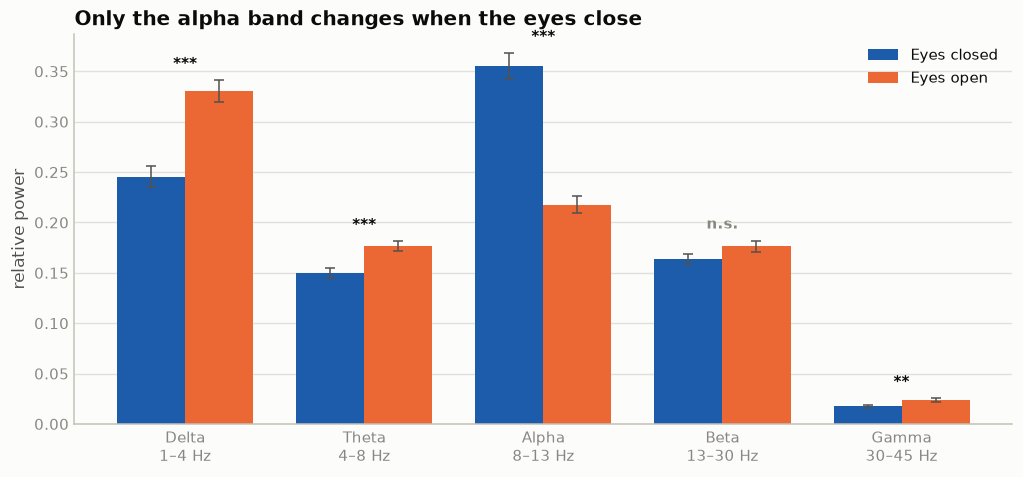

In [19]:
bands = list(BANDS.keys())
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(bands)); w = 0.38
means = {st: [ep_state[ep_state.state==st][f"{b}_rel"].mean() for b in bands] for st in ["closed","open"]}
sems  = {st: [ep_state[ep_state.state==st][f"{b}_rel"].sem()  for b in bands] for st in ["closed","open"]}
ax.bar(x-w/2, means["closed"], w, yerr=sems["closed"], color=C_STATE["closed"], label="Eyes closed",
       capsize=3, error_kw=dict(lw=1, ecolor=INK2))
ax.bar(x+w/2, means["open"], w, yerr=sems["open"], color=C_STATE["open"], label="Eyes open",
       capsize=3, error_kw=dict(lw=1, ecolor=INK2))
for i,b in enumerate(bands):
    a = ep_state[ep_state.state=="closed"][f"{b}_rel"].dropna()
    o = ep_state[ep_state.state=="open"][f"{b}_rel"].dropna()
    p = stats.mannwhitneyu(a,o).pvalue
    star = "***" if p<1e-3 else "**" if p<1e-2 else "*" if p<0.05 else "n.s."
    yy = max(means["closed"][i],means["open"][i]) + max(sems["closed"][i],sems["open"][i]) + 0.012
    ax.text(i, yy, star, ha="center", color=INK if p<0.05 else MUTED, fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([f"{b}\n{BANDS[b][0]}–{BANDS[b][1]} Hz" for b in bands])
style(ax); ax.set_ylabel("relative power"); ax.legend(loc="upper right")
ax.set_title("Only the alpha band changes when the eyes close", loc="left")
plt.show()


## 6 · 🎼 Music and the alpha rhythm

For each subject we average the relative alpha of their **eyes-closed** epochs (the state that best reveals relaxation) in each condition. Lines connect each subject across the 4 conditions; the **Friedman test** evaluates the global effect of music.

> **Read the p-value on the plot before concluding anything.** With the sample doubled to 14 subjects this is the best-powered test in the notebook, but between-person variability in alpha is large. The Friedman test uses only subjects with all 4 conditions (Shalva is dropped), and the meditation-vs-stress contrast is reported with its effect size so the magnitude is visible regardless of significance.

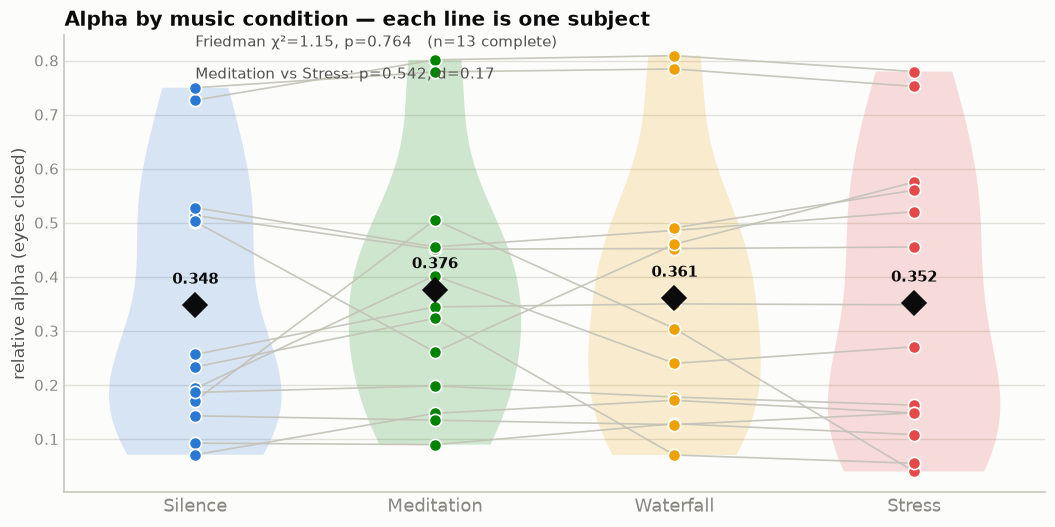

Condition means (eyes-closed alpha):
condition
nomusic       0.3477
meditation    0.3763
waterfall     0.3607
stress        0.3516

Friedman χ²=1.154, p=0.7641 (n=13)
Meditation vs Stress: Wilcoxon p=0.5417, d=0.168


In [20]:
cc = ep_state[ep_state.state=="closed"]
pv = cc.pivot_table(index="subject", columns="condition", values="Alpha_rel",
                    aggfunc="mean", observed=False)[CONDITIONS]

fig, ax = plt.subplots(figsize=(11.5, 5.4))
xpos = np.arange(4)
parts = ax.violinplot([pv[c].dropna().values for c in CONDITIONS], positions=xpos,
                      widths=0.72, showextrema=False)
for i,b in enumerate(parts["bodies"]):
    b.set_facecolor(C_COND[CONDITIONS[i]]); b.set_alpha(0.18); b.set_edgecolor("none")
for s in pv.index:
    ax.plot(xpos, pv.loc[s].values, "-", color=AXIS, lw=1.1, zorder=2, alpha=0.9)
for i,c in enumerate(CONDITIONS):
    ax.scatter([i]*len(pv), pv[c].values, s=64, color=C_COND[c], ec="white", lw=1.1, zorder=3)
mrs = pv.mean()
ax.plot(xpos, mrs.values, "D", ms=11, color=INK, zorder=4)
for i,c in enumerate(CONDITIONS):
    ax.annotate(f"{mrs[c]:.3f}", (i, mrs[c]), textcoords="offset points", xytext=(0,14),
                ha="center", fontsize=9.5, fontweight="bold", color=INK)
ax.set_xticks(xpos); ax.set_xticklabels([COND_EN[c] for c in CONDITIONS], fontsize=12)
style(ax); ax.set_ylabel("relative alpha (eyes closed)")
pvc = pv.dropna()          # repeated-measures tests need complete cases
fr = stats.friedmanchisquare(*[pvc[c].values for c in CONDITIONS])
wm = stats.wilcoxon(pvc["meditation"], pvc["stress"])
ax.set_title("Alpha by music condition — each line is one subject", loc="left")
ax.text(0.0, ax.get_ylim()[1], f"Friedman χ²={fr.statistic:.2f}, p={fr.pvalue:.3f}   (n={len(pvc)} complete)",
        fontsize=10, color=INK2, va="top")
ax.text(0.0, ax.get_ylim()[1]*0.93,
        f"Meditation vs Stress: p={wm.pvalue:.3f}, d={cohend(pvc['meditation'],pvc['stress']):.2f}",
        fontsize=10, color=INK2, va="top")
plt.show()
print(f"Condition means (eyes-closed alpha):\n{mrs.round(4).to_string()}")
print(f"\nFriedman χ²={fr.statistic:.3f}, p={fr.pvalue:.4f} (n={len(pvc)})")
print(f"Meditation vs Stress: Wilcoxon p={wm.pvalue:.4f}, d={cohend(pvc['meditation'],pvc['stress']):.3f}")


### Spectrogram gallery

The same person across the 4 conditions. The vertical axis is frequency (0–30 Hz), color is energy. The alpha strip (8–12 Hz) is highlighted; the ribbon on top marks eyes closed (blue) / open (orange). Brighter horizontal bands in alpha appear during closed blocks.

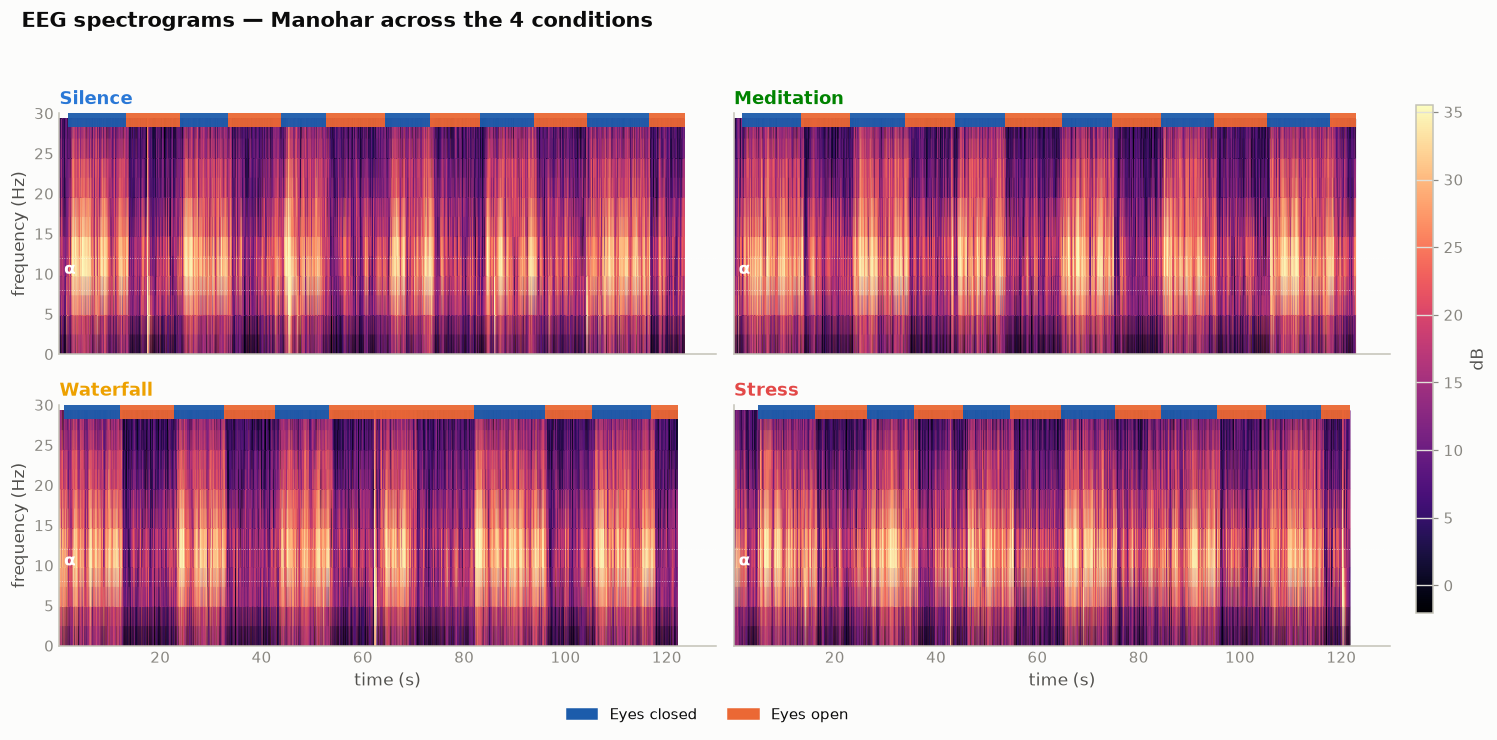

In [21]:
GSUB = "Manohar"
fig, axs = plt.subplots(2, 2, figsize=(13, 6.6), sharex=True, sharey=True)
axs = axs.ravel()
for k, c in enumerate(CONDITIONS):
    fs, eeg_raw, _, ev = find_rec(GSUB, c)
    eeg = preprocess_eeg(eeg_raw, fs)
    f, tt, Sxx = spectrogram(eeg, fs, nperseg=1024, noverlap=896)
    sel = f <= 30
    S = 10*np.log10(Sxx[sel]+1e-12)
    ax = axs[k]
    pcm = ax.pcolormesh(tt, f[sel], S, cmap="magma", shading="gouraud",
                        vmin=np.percentile(S,5), vmax=np.percentile(S,99))
    ax.axhline(8, color="white", lw=0.6, ls=":", alpha=0.6); ax.axhline(12, color="white", lw=0.6, ls=":", alpha=0.6)
    for (s,e,st) in epochs_from_events(ev, len(eeg), fs):
        if st in C_STATE:
            ax.add_patch(plt.Rectangle((s,28.3),e-s,1.7,color=C_STATE[st],lw=0,alpha=0.95,clip_on=False))
    ax.set_title(COND_EN[c], loc="left", color=C_COND[c], fontsize=12)
    ax.set_ylim(0,30); ax.grid(False); ax.tick_params(length=0)
    for sp in ax.spines.values(): sp.set_color(AXIS)
    if k in (2,3): ax.set_xlabel("time (s)")
    if k in (0,2): ax.set_ylabel("frequency (Hz)")
    ax.text(1, 10, "α", color="white", fontweight="bold", fontsize=11)
fig.suptitle(f"EEG spectrograms — {GSUB} across the 4 conditions", x=0.02, ha="left",
             fontsize=14, fontweight="bold")
cax = fig.add_axes([0.995, 0.15, 0.012, 0.7]); fig.colorbar(pcm, cax=cax, label="dB")
leg = [Patch(color=C_STATE["closed"], label="Eyes closed"), Patch(color=C_STATE["open"], label="Eyes open")]
fig.legend(handles=leg, loc="lower center", ncol=2, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout(rect=[0,0.02,0.99,0.95]); plt.show()


## 7 · 💓 The heart and music

Using the robust autocorrelation heart rate on **good-quality ECG recordings only**, we compare mean heart rate across conditions. Lines connect each subject; the black diamond is the group mean. The right panel shows each subject's change relative to their own silent baseline.

> Only subjects whose ECG passes quality control in **all four** conditions enter this comparison, so the n here is smaller than 14.

HR by condition (bpm):
condition
nomusic       80.51
meditation    80.43
waterfall     79.78
stress        81.12
Friedman p=0.8126 (n=11)


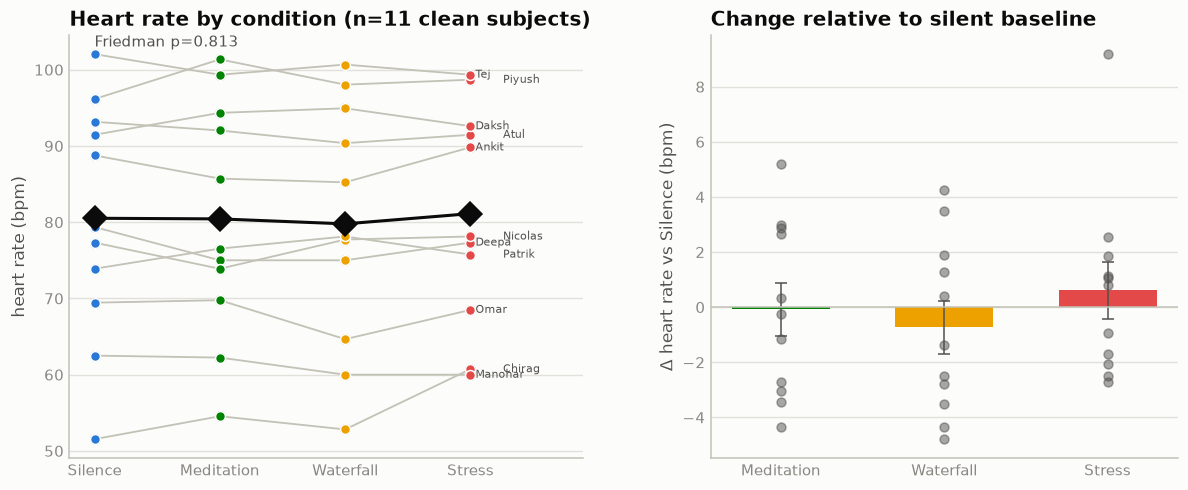

In [22]:
good = rec[rec.ecg_ok].copy()
hr_pv = good.pivot_table(index="subject", columns="condition", values="hr", observed=False)[CONDITIONS]
hr_pv = hr_pv.dropna(how="any")          # subjects with all 4 conditions of good quality

fig, axs = plt.subplots(1, 2, figsize=(13, 5.0), gridspec_kw=dict(width_ratios=[1.1,1], wspace=0.26))
ax = axs[0]; xpos = np.arange(4)
for i, s in enumerate(hr_pv.sort_values("stress").index):
    ax.plot(xpos, hr_pv.loc[s].values, "-o", color=AXIS, mfc="white", mec=INK2, ms=6, lw=1.2, zorder=2)
    ax.annotate(s, (3.04 + 0.22*(i % 2), hr_pv.loc[s,"stress"]), fontsize=7.5, color=INK2, va="center")
mrs = hr_pv.mean()
ax.plot(xpos, mrs.values, "D-", ms=11, color=INK, lw=2, zorder=4)
for i,c in enumerate(CONDITIONS):
    ax.scatter([i]*len(hr_pv), hr_pv[c].values, s=42, color=C_COND[c], ec="white", lw=1, zorder=3)
ax.set_xticks(xpos); ax.set_xticklabels([COND_EN[c] for c in CONDITIONS]); ax.set_xlim(-0.2,3.9)
style(ax); ax.set_ylabel("heart rate (bpm)")
fr = stats.friedmanchisquare(*[hr_pv[c].values for c in CONDITIONS])
ax.set_title(f"Heart rate by condition (n={len(hr_pv)} clean subjects)", loc="left")
ax.text(0.0, ax.get_ylim()[1], f"Friedman p={fr.pvalue:.3f}", fontsize=10, color=INK2, va="top")
print(f"HR by condition (bpm):\n{hr_pv.mean().round(2).to_string()}\nFriedman p={fr.pvalue:.4f} (n={len(hr_pv)})")

# within-subject change vs silence baseline
ax2 = axs[1]
delta = hr_pv.sub(hr_pv["nomusic"], axis=0)[["meditation","waterfall","stress"]]
xb = np.arange(3)
mb = delta.mean(); sb = delta.sem()
bcol = [C_COND[c] for c in ["meditation","waterfall","stress"]]
ax2.bar(xb, mb.values, 0.6, yerr=sb.values, color=bcol, capsize=4, error_kw=dict(lw=1,ecolor=INK2))
for i,c in enumerate(["meditation","waterfall","stress"]):
    ax2.scatter([i]*len(delta), delta[c].values, s=34, color=INK2, alpha=0.5, zorder=3)
ax2.axhline(0, color=AXIS, lw=1)
ax2.set_xticks(xb); ax2.set_xticklabels([COND_EN[c] for c in ["meditation","waterfall","stress"]])
style(ax2); ax2.set_ylabel("Δ heart rate vs Silence (bpm)")
ax2.set_title("Change relative to silent baseline", loc="left")
plt.show()


### Heart-rate variability — Poincaré plots

Each point plots one RR interval against the next (RRₙ vs RRₙ₊₁). A **tight cloud** = low variability (higher arousal); a **spread cloud** = high variability (relaxed, healthy vagal tone). Shown for one clean subject across conditions, with the RMSSD summary alongside.

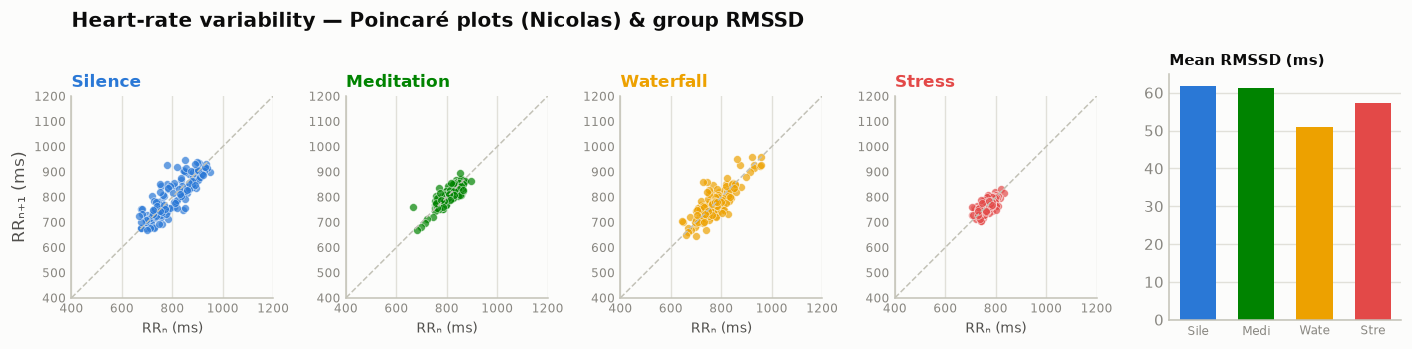

In [23]:
PSUB = "Nicolas"
fig = plt.figure(figsize=(13, 3.6))
gs = GridSpec(1, 5, width_ratios=[1,1,1,1,1.15], wspace=0.35, left=0.05, right=0.98, bottom=0.2, top=0.82)
lims = [400, 1200]
for k,c in enumerate(CONDITIONS):
    fs, _, ecg_raw, _ = find_rec(PSUB, c)
    rr = clean_rr(detect_rpeaks(ecg_raw, fs), fs)
    ax = fig.add_subplot(gs[k])
    if len(rr) > 2:
        ax.scatter(rr[:-1], rr[1:], s=26, color=C_COND[c], alpha=0.7, ec="white", lw=0.4)
    ax.plot(lims, lims, color=AXIS, lw=1, ls="--")
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_title(COND_EN[c], color=C_COND[c], fontsize=11, loc="left")
    style(ax, grid_axis="both"); ax.tick_params(labelsize=8)
    if k==0: ax.set_ylabel("RRₙ₊₁ (ms)")
    ax.set_xlabel("RRₙ (ms)", fontsize=9)

axr = fig.add_subplot(gs[4])
rm = good.pivot_table(index="subject", columns="condition", values="rmssd", observed=False)[CONDITIONS].mean()
axr.bar(range(4), rm.values, 0.62, color=[C_COND[c] for c in CONDITIONS])
axr.set_xticks(range(4)); axr.set_xticklabels([COND_EN[c][:4] for c in CONDITIONS], fontsize=8)
style(axr); axr.set_title("Mean RMSSD (ms)", fontsize=10, loc="left")
fig.suptitle(f"Heart-rate variability — Poincaré plots ({PSUB}) & group RMSSD", x=0.05, ha="left",
             fontsize=13, fontweight="bold")
plt.show()


## 8 · 🧠💓 The brain–heart axis

Do relaxed brains (more alpha) go with slower hearts? Because subjects differ hugely in baseline alpha and heart rate, we **z-score within each subject** so the coupling is not driven by between-person differences. Each point is one recording, colored by condition.

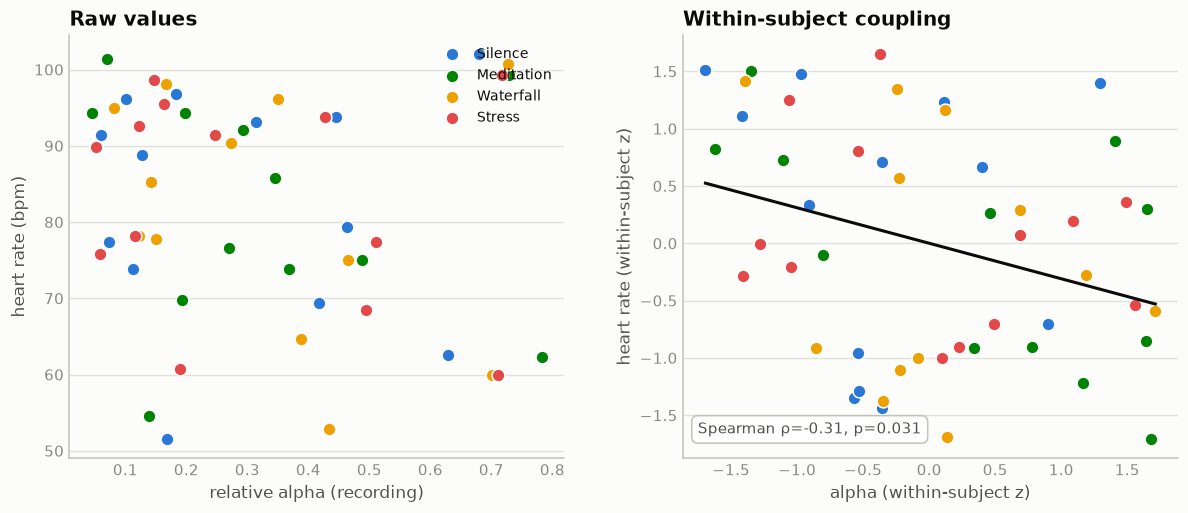

In [24]:
bh = rec[rec.ecg_ok].dropna(subset=["hr","alpha_rel"]).copy()
# within-subject z-scores
def zc(g, col):
    v = g[col]; return (v - v.mean())/v.std(ddof=0) if v.std(ddof=0)>0 else v*0
bh["alpha_z"] = bh.groupby("subject", observed=False).apply(lambda g: zc(g,"alpha_rel")).reset_index(level=0, drop=True)
bh["hr_z"]    = bh.groupby("subject", observed=False).apply(lambda g: zc(g,"hr")).reset_index(level=0, drop=True)

fig, axs = plt.subplots(1, 2, figsize=(13, 5.0), gridspec_kw=dict(width_ratios=[1,1], wspace=0.24))
# raw
ax = axs[0]
for c in CONDITIONS:
    d = bh[bh.condition==c]
    ax.scatter(d["alpha_rel"], d["hr"], s=70, color=C_COND[c], ec="white", lw=1, label=COND_EN[c])
style(ax); ax.set_xlabel("relative alpha (recording)"); ax.set_ylabel("heart rate (bpm)")
ax.set_title("Raw values", loc="left"); ax.legend(loc="upper right", fontsize=9)

# within-subject z
ax2 = axs[1]
for c in CONDITIONS:
    d = bh[bh.condition==c]
    ax2.scatter(d["alpha_z"], d["hr_z"], s=70, color=C_COND[c], ec="white", lw=1, label=COND_EN[c])
x = bh["alpha_z"].values; yv = bh["hr_z"].values
m,b = np.polyfit(x, yv, 1); xs = np.linspace(x.min(), x.max(), 50)
ax2.plot(xs, m*xs+b, color=INK, lw=2, zorder=1)
r, p = stats.spearmanr(x, yv)
style(ax2); ax2.set_xlabel("alpha (within-subject z)"); ax2.set_ylabel("heart rate (within-subject z)")
ax2.set_title("Within-subject coupling", loc="left")
ax2.text(0.03, 0.05, f"Spearman ρ={r:.2f}, p={p:.3f}", transform=ax2.transAxes,
         fontsize=10, color=INK2, va="bottom",
         bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=AXIS, lw=1))
plt.show()


### Per-subject view — every epoch in the alpha–heart plane

The most direct way to ask *"does eye state change the brain and the heart differently?"*: plot **one point per epoch**, alpha on x and heart rate on y, split by eyes closed vs open. The large diamonds are the per-state means. A **horizontal gap** between them means alpha moved with eye state; a **vertical gap** means heart rate moved. The final panel summarizes every subject as Δ(closed − open).

The expected pattern: eye closure shifts the cloud **rightward (more alpha)** but barely up or down — **heart rate largely unchanged by eye state**. Subjects whose ECG failed quality control are flagged; any vertical shift they show is a detection artifact, not physiology.

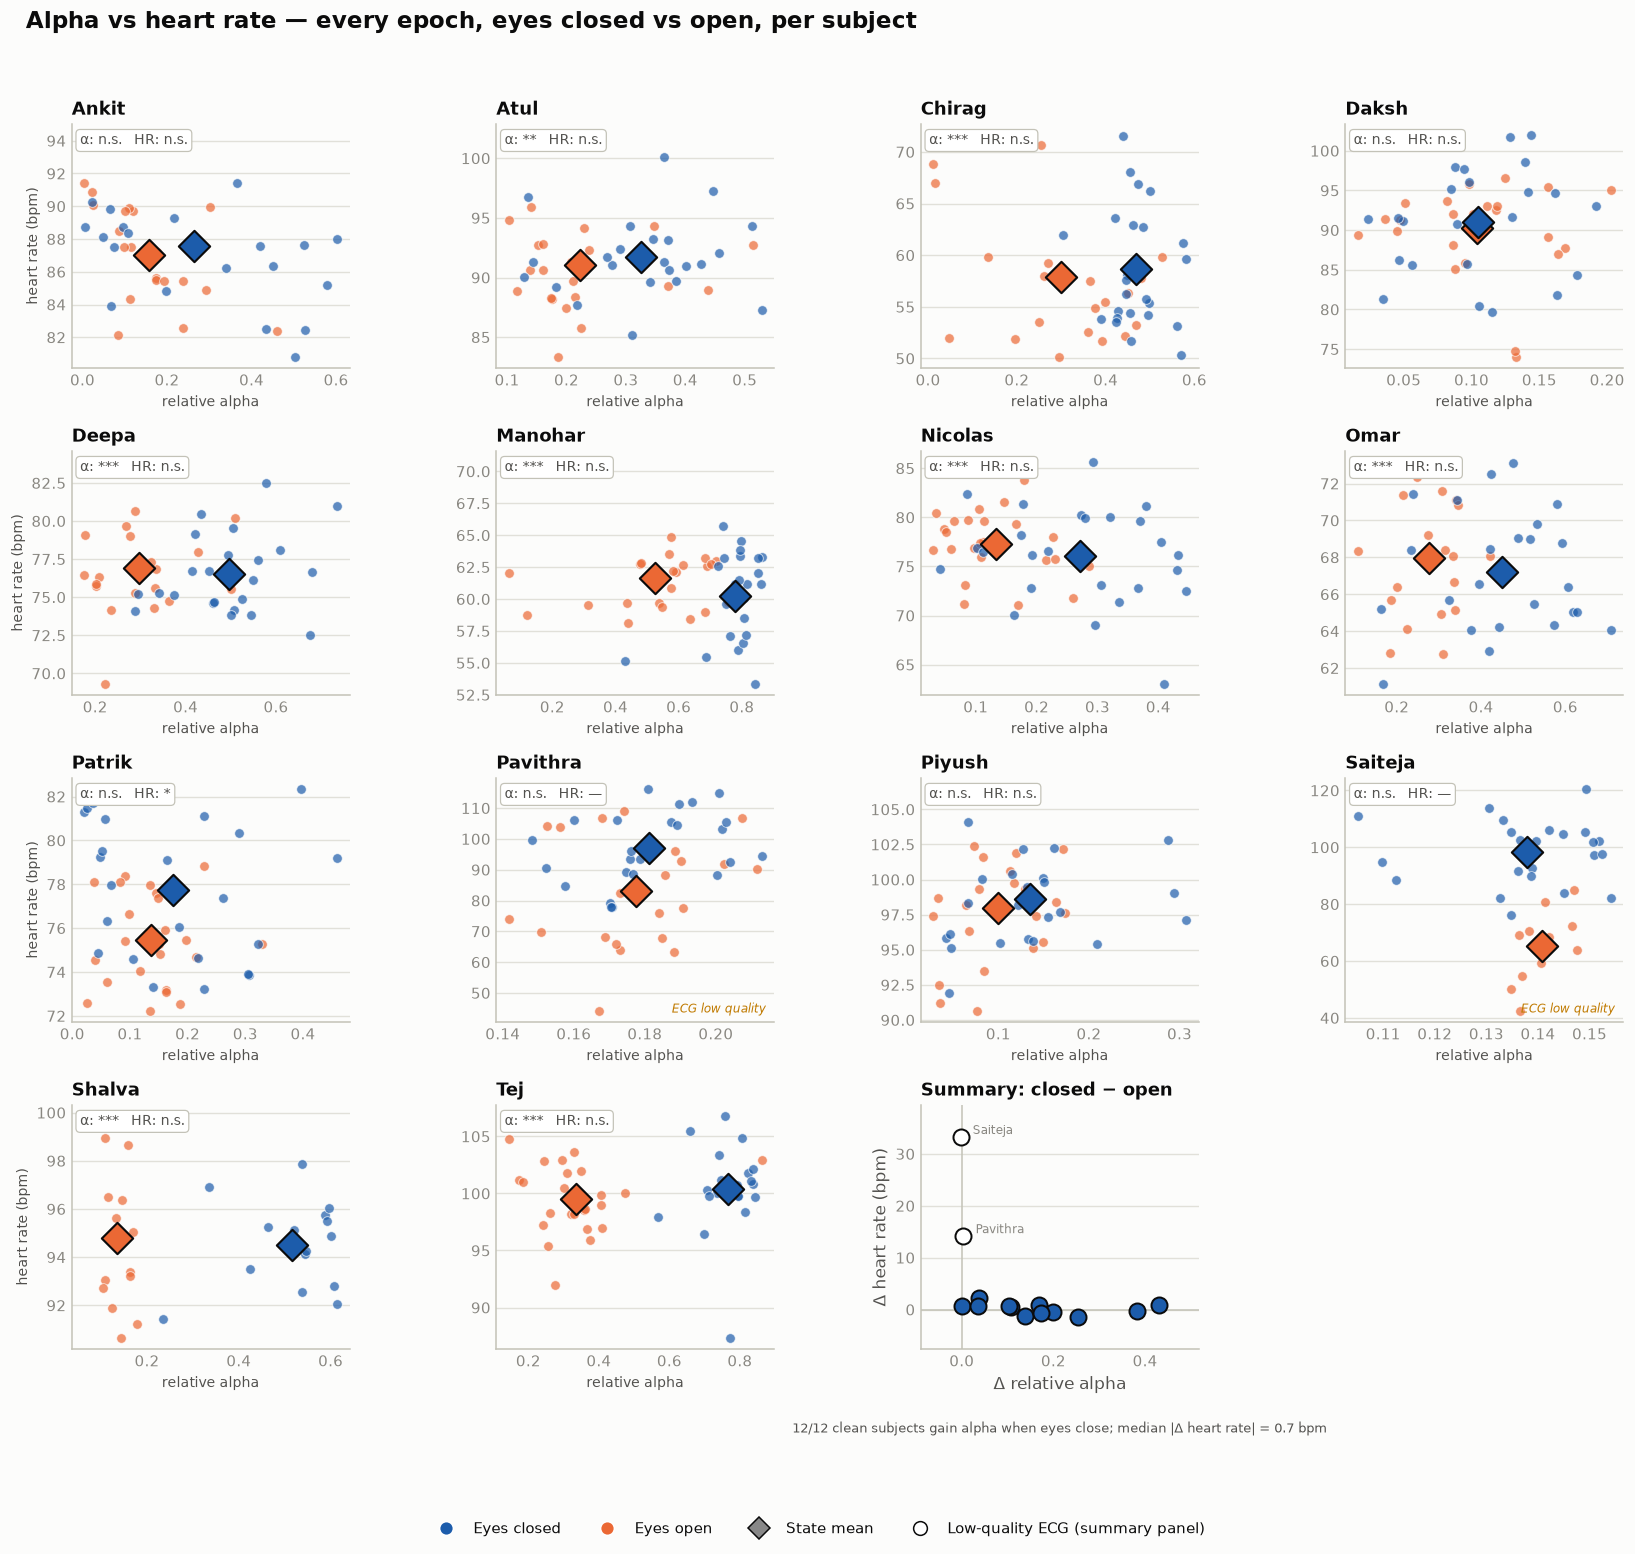

In [25]:
from matplotlib.lines import Line2D
BAD = set(rec.groupby("subject")["ecg_ok"].mean().pipe(lambda s: s[s < 1.0].index))
subs = sorted(ep_state.subject.unique())
dd_all = ep_state.dropna(subset=["hr","Alpha_rel"])
star = lambda p: "***" if p<1e-3 else "**" if p<1e-2 else "*" if p<0.05 else "n.s."

NC = 4
NR = int(np.ceil((len(subs) + 1) / NC))          # +1 for the summary panel
fig, axs = plt.subplots(NR, NC, figsize=(15, 3.5*NR)); axs = axs.ravel()
summary = []
for k, s in enumerate(subs):
    ax = axs[k]; d = dd_all[dd_all.subject == s]
    for st in ("open","closed"):
        g = d[d.state == st]
        ax.scatter(g["Alpha_rel"], g["hr"], s=40, color=C_STATE[st], alpha=0.70, ec="white", lw=0.6, zorder=2)
        if len(g):
            ax.scatter(g["Alpha_rel"].mean(), g["hr"].mean(), s=210, marker="D",
                       color=C_STATE[st], ec=INK, lw=1.4, zorder=4)
    ac, ao = d[d.state=="closed"]["Alpha_rel"], d[d.state=="open"]["Alpha_rel"]
    hc, ho = d[d.state=="closed"]["hr"], d[d.state=="open"]["hr"]
    pa = stats.mannwhitneyu(ac, ao).pvalue; ph = stats.mannwhitneyu(hc, ho).pvalue
    summary.append(dict(subject=s, da=ac.mean()-ao.mean(), dh=hc.mean()-ho.mean(), bad=s in BAD))
    style(ax); ax.set_title(s, loc="left", fontweight="bold", fontsize=12, pad=6)
    ax.text(0.03, 0.96, f"α: {star(pa)}   HR: {'—' if s in BAD else star(ph)}",
            transform=ax.transAxes, va="top", fontsize=9, color=INK2,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=AXIS, lw=0.8))
    if s in BAD:
        ax.text(0.97, 0.04, "ECG low quality", transform=ax.transAxes, ha="right",
                fontsize=8, color="#c07a00", style="italic")
    ax.set_xlabel("relative alpha", fontsize=9)
    if k % NC == 0: ax.set_ylabel("heart rate (bpm)", fontsize=9)

sm = pd.DataFrame(summary); ax = axs[len(subs)]          # summary goes right after the subjects
for j in range(len(subs)+1, len(axs)): axs[j].axis("off")  # hide unused slots
ax.axhline(0, color=AXIS, lw=1); ax.axvline(0, color=AXIS, lw=1)
for _, r in sm.iterrows():
    ax.scatter(r["da"], r["dh"], s=110, color=("white" if r["bad"] else C_STATE["closed"]),
               ec=INK, lw=1.3, zorder=3)
    if r["bad"]:      # label only the flagged outliers — the clean subjects overlap on the 0 line
        ax.annotate(r["subject"], (r["da"], r["dh"]), textcoords="offset points", xytext=(8,2),
                    fontsize=8, color=MUTED)
style(ax); ax.margins(x=0.20, y=0.18)
ax.set_title("Summary: closed − open", loc="left", fontweight="bold", fontsize=12, pad=6)
ax.set_xlabel("Δ relative alpha"); ax.set_ylabel("Δ heart rate (bpm)")
clean = sm[~sm["bad"]]
ax.text(0.5, -0.34, f"{(clean['da']>0).sum()}/{len(clean)} clean subjects gain alpha when eyes close; "
        f"median |Δ heart rate| = {clean['dh'].abs().median():.1f} bpm",
        transform=ax.transAxes, ha="center", fontsize=8.5, color=INK2)

h = [Line2D([0],[0],marker="o",ls="",mfc=C_STATE["closed"],mec="white",ms=9,label="Eyes closed"),
     Line2D([0],[0],marker="o",ls="",mfc=C_STATE["open"],mec="white",ms=9,label="Eyes open"),
     Line2D([0],[0],marker="D",ls="",mfc="#888",mec=INK,ms=10,label="State mean"),
     Line2D([0],[0],marker="o",ls="",mfc="white",mec=INK,ms=9,label="Low-quality ECG (summary panel)")]
fig.legend(handles=h, loc="lower center", ncol=4, fontsize=10, frameon=False, bbox_to_anchor=(0.5,-0.02))
fig.suptitle("Alpha vs heart rate — every epoch, eyes closed vs open, per subject",
             x=0.02, ha="left", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0,0.04,1,0.96]); plt.show()


## 9 · Machine learning — and why the obvious classifier fails

Look back at §8: within each subject the closed and open clouds separate cleanly. So why does a classifier trained across subjects barely beat chance?

**Because "how much alpha" means something different for every person.** Relative alpha spans ≈0.02–0.20 in one subject and ≈0.06–0.86 in another. One person's *eyes-open* epochs can carry more alpha than another's *eyes-closed* epochs, so no single global threshold can work. A model trained on raw values across people spends its capacity on between-person differences instead of on eye state.

The fix is **per-subject normalization**: z-score each subject's features using only that subject's own distribution. This uses **no labels**, so it is not leakage — it is the standard "calibration" step in any real BCI, where a headset is tuned to its wearer before use.

We compare three regimes:

| Regime | What it asks |
|---|---|
| **Leaky random split** | inflated baseline — test epochs share subjects with training |
| **LOSO, raw features** | can a model transfer to a *new person* with no calibration? |
| **LOSO, within-subject z-scored** | can it transfer given a short calibration on the new person? |

and then fit a **separate model per subject** to reveal who is decodable at all.

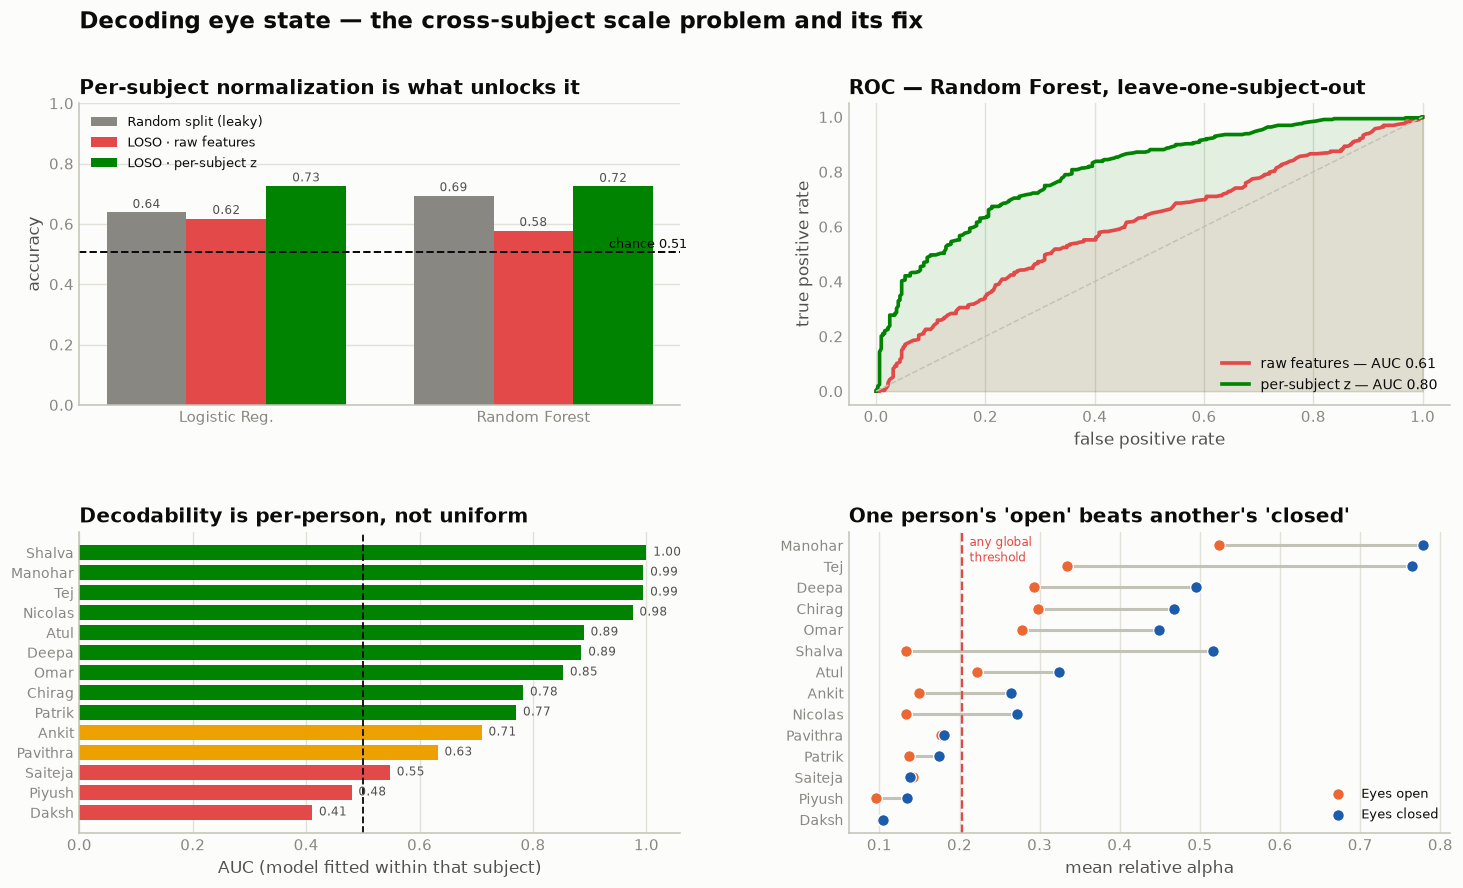

chance = 0.505
Logistic Reg.  leaky=0.638 | LOSO raw=0.618 (AUC 0.642) | LOSO z=0.726 (AUC 0.801)
Random Forest  leaky=0.693 | LOSO raw=0.578 (AUC 0.606) | LOSO z=0.724 (AUC 0.802)

Per-subject models: mean AUC = 0.780 | 9/14 subjects at AUC >= 0.75


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold, LeaveOneGroupOut
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score

feat_cols = [f"{b}_rel" for b in BANDS] + list(BANDS.keys())
d = ep_state.dropna(subset=feat_cols).copy()
y      = (d["state"]=="closed").astype(int).values
groups = d["subject"].values
X_raw  = d[feat_cols].values
# within-subject z-score — unsupervised (no labels used), i.e. a calibration step, not leakage
X_z = d.groupby("subject")[feat_cols].transform(
        lambda v: (v - v.mean()) / (v.std(ddof=0) if v.std(ddof=0) > 0 else 1)).values

logo, skf = LeaveOneGroupOut(), StratifiedKFold(5, shuffle=True, random_state=0)
rf = lambda: RandomForestClassifier(300, random_state=0)
lr = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
chance = max(np.mean(y), 1-np.mean(y))
MODELS = [("Logistic Reg.", lr), ("Random Forest", rf)]

res, roc_store = {}, {}
for name, mk in MODELS:
    a_leak = accuracy_score(y, cross_val_predict(mk(), X_raw, y, cv=skf))
    p_raw  = cross_val_predict(mk(), X_raw, y, cv=logo, groups=groups, method="predict_proba")[:,1]
    p_z    = cross_val_predict(mk(), X_z,   y, cv=logo, groups=groups, method="predict_proba")[:,1]
    res[name] = dict(leaky=a_leak,
                     loso_raw=accuracy_score(y,(p_raw>=.5).astype(int)),
                     loso_z  =accuracy_score(y,(p_z  >=.5).astype(int)),
                     auc_raw =roc_auc_score(y,p_raw), auc_z=roc_auc_score(y,p_z))
    roc_store[name] = (p_raw, p_z)

# per-subject models (5-fold inside each person)
per_sub = []
for s in sorted(d["subject"].unique()):
    m  = (d["subject"]==s).values
    ys = y[m]
    if len(np.unique(ys)) < 2 or len(ys) < 12: continue
    p = cross_val_predict(rf(), X_raw[m], ys, cv=skf, method="predict_proba")[:,1]
    per_sub.append(dict(subject=s, auc=roc_auc_score(ys,p), n=len(ys)))
per_sub = pd.DataFrame(per_sub).sort_values("auc", ascending=False)

fig = plt.figure(figsize=(14, 8.4))
gs = GridSpec(2, 2, hspace=0.42, wspace=0.28, left=0.08, right=0.97, top=0.88, bottom=0.09)

# (a) the three regimes
ax = fig.add_subplot(gs[0,0]); names = list(res); xb = np.arange(len(names)); w = 0.26
ax.bar(xb-w, [res[n]["leaky"]    for n in names], w, color=MUTED,             label="Random split (leaky)")
ax.bar(xb,   [res[n]["loso_raw"] for n in names], w, color=C_COND["stress"],  label="LOSO · raw features")
ax.bar(xb+w, [res[n]["loso_z"]   for n in names], w, color=C_COND["meditation"], label="LOSO · per-subject z")
for i,n in enumerate(names):
    for off,k in [(-w,"leaky"),(0,"loso_raw"),(w,"loso_z")]:
        ax.text(i+off, res[n][k]+0.015, f"{res[n][k]:.2f}", ha="center", fontsize=8, color=INK2)
ax.axhline(chance, color=INK, ls="--", lw=1.3)
ax.text(len(names)-0.5, chance+0.015, f"chance {chance:.2f}", color=INK, fontsize=8.5, ha="right")
ax.set_xticks(xb); ax.set_xticklabels(names); ax.set_ylim(0,1)
style(ax); ax.set_ylabel("accuracy"); ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("Per-subject normalization is what unlocks it", loc="left")

# (b) ROC raw vs z (Random Forest)
ax2 = fig.add_subplot(gs[0,1])
p_raw, p_z = roc_store["Random Forest"]
for p, col, lab in [(p_raw, C_COND["stress"], "raw features"), (p_z, C_COND["meditation"], "per-subject z")]:
    fpr, tpr, _ = roc_curve(y, p)
    ax2.plot(fpr, tpr, color=col, lw=2.4, label=f"{lab} — AUC {auc(fpr,tpr):.2f}")
    ax2.fill_between(fpr, tpr, color=col, alpha=0.10)
ax2.plot([0,1],[0,1], color=AXIS, ls="--", lw=1)
style(ax2, grid_axis="both"); ax2.set_xlabel("false positive rate"); ax2.set_ylabel("true positive rate")
ax2.set_title("ROC — Random Forest, leave-one-subject-out", loc="left"); ax2.legend(loc="lower right", fontsize=9)

# (c) who is decodable at all
ax3 = fig.add_subplot(gs[1,0])
cols = [C_COND["meditation"] if a>=0.75 else (C_COND["waterfall"] if a>=0.6 else C_COND["stress"])
        for a in per_sub["auc"]]
ax3.barh(range(len(per_sub)), per_sub["auc"], color=cols, height=0.72)
ax3.axvline(0.5, color=INK, ls="--", lw=1.2)
ax3.set_yticks(range(len(per_sub))); ax3.set_yticklabels(per_sub["subject"], fontsize=9)
ax3.invert_yaxis(); style(ax3, grid_axis="x"); ax3.set_xlim(0,1.06)
for i,a in enumerate(per_sub["auc"]):
    ax3.text(a+0.012, i, f"{a:.2f}", va="center", fontsize=8, color=INK2)
ax3.set_xlabel("AUC (model fitted within that subject)")
ax3.set_title("Decodability is per-person, not uniform", loc="left")

# (d) why raw thresholds cannot transfer
ax4 = fig.add_subplot(gs[1,1])
mm = d.groupby(["subject","state"])["Alpha_rel"].mean().unstack()
mm = mm.loc[mm.mean(axis=1).sort_values().index]
yy = np.arange(len(mm))
for i,(s,row) in enumerate(mm.iterrows()):
    ax4.plot([row["open"], row["closed"]], [i,i], color=AXIS, lw=2, zorder=1)
ax4.scatter(mm["open"], yy, s=58, color=C_STATE["open"], ec="white", lw=0.8, zorder=3, label="Eyes open")
ax4.scatter(mm["closed"], yy, s=58, color=C_STATE["closed"], ec="white", lw=0.8, zorder=3, label="Eyes closed")
ax4.set_yticks(yy); ax4.set_yticklabels(mm.index, fontsize=9)
style(ax4, grid_axis="x"); ax4.set_xlabel("mean relative alpha")
ax4.set_title("One person's 'open' beats another's 'closed'", loc="left")
ax4.legend(fontsize=8.5, loc="lower right")
# a global threshold drawn through the middle misclassifies whole subjects
thr = float(d["Alpha_rel"].median())
ax4.axvline(thr, color=C_COND["stress"], ls="--", lw=1.5)
ax4.text(thr+0.01, len(mm)-0.5, "any global\nthreshold", color=C_COND["stress"], fontsize=8, va="top")

fig.suptitle("Decoding eye state — the cross-subject scale problem and its fix",
             x=0.08, ha="left", fontsize=15, fontweight="bold")
plt.show()

print(f"chance = {chance:.3f}")
for n in names:
    r = res[n]
    print(f"{n:14s} leaky={r['leaky']:.3f} | LOSO raw={r['loso_raw']:.3f} (AUC {r['auc_raw']:.3f}) "
          f"| LOSO z={r['loso_z']:.3f} (AUC {r['auc_z']:.3f})")
print(f"\nPer-subject models: mean AUC = {per_sub['auc'].mean():.3f} "
      f"| {(per_sub['auc']>=0.75).sum()}/{len(per_sub)} subjects at AUC >= 0.75")


### 9.1 · An expert-grade decoding pipeline

The diagnosis above says the representation is the bottleneck, not the classifier. So we rebuild the feature side properly. Three changes, each measured separately:

**(a) Aperiodic / periodic decomposition (FOOOF-style).** An EEG spectrum is a `1/f` background plus oscillatory peaks on top. The `1/f` **exponent and offset vary enormously between people** and contaminate every band-power measure. We fit the background in log–log space (excluding 7–14 Hz so the alpha peak doesn't drag the line), then measure the **alpha peak prominence *above* that fit** — a quantity that is subject-comparable by construction — plus each person's **individual alpha frequency (IAF)** and an IAF-centred alpha band.

**(b) A richer descriptor set** — self-normalising band ratios, spectral entropy / edge / centroid, Hjorth mobility & complexity, and alpha-envelope statistics (variability, burst fraction, skew). 40 features in total.

**(c) Sliding windows.** Instead of one feature vector per ~10 s epoch, we take **4 s windows with 50 % overlap** (2,289 windows from 649 epochs) and average the window probabilities back up to the epoch. More training samples, and averaging suppresses per-window noise.

We then evaluate every combination of **normalisation × model** under leave-one-subject-out, scoring at the epoch level.

In [27]:
WIN_S, STEP_S = 4.0, 2.0          # sliding window / hop, seconds

# Robust log-log fit of the 1/f background, excluding the alpha range.
# Returns (exponent, offset, flattened log-spectrum).
def aperiodic_fit(f, psd, lo=2., hi=40., excl=(7.,14.)):
    m = (f>=lo)&(f<=hi)&(psd>0)
    lf, lp = np.log10(f[m]), np.log10(psd[m])
    keep = ~((f[m]>=excl[0])&(f[m]<=excl[1]))
    if keep.sum() < 5: return np.nan, np.nan, np.full(len(f), np.nan)
    sl, ic = np.polyfit(lf[keep], lp[keep], 1)
    resid  = lp[keep]-(sl*lf[keep]+ic)
    mad    = np.median(np.abs(resid-np.median(resid)))+1e-12
    k2     = np.abs(resid-np.median(resid)) < 2.5*mad          # 2nd pass: drop residual peaks
    if k2.sum() >= 5: sl, ic = np.polyfit(lf[keep][k2], lp[keep][k2], 1)
    with np.errstate(divide="ignore"):
        flat = np.log10(np.maximum(psd,1e-20)) - (sl*np.log10(np.maximum(f,1e-9))+ic)
    return -sl, ic, flat

def _hjorth(x):
    d1 = np.diff(x); d2 = np.diff(d1)
    v0,v1,v2 = np.var(x)+1e-20, np.var(d1)+1e-20, np.var(d2)+1e-20
    mob = np.sqrt(v1/v0)
    return mob, (np.sqrt(v2/v1)/mob if mob>0 else np.nan)

def window_features(x, fs):
    f, psd = welch(x, fs, nperseg=int(min(len(x), fs*2)), noverlap=int(min(len(x), fs*2))//2)
    s = (f>=1)&(f<=45); f, psd = f[s], psd[s]
    tot = np.trapz(psd,f)+1e-20; out = {}; bp = {}
    for n,(lo,hi) in BANDS.items():
        m = (f>=lo)&(f<hi); bp[n] = np.trapz(psd[m], f[m])
        out[f"bp_{n.lower()}"]=bp[n]; out[f"logbp_{n.lower()}"]=np.log10(bp[n]+1e-20)
        out[f"rel_{n.lower()}"]=bp[n]/tot
    out["ratio_alpha_beta"]  = bp["Alpha"]/(bp["Beta"]+1e-20)
    out["ratio_alpha_theta"] = bp["Alpha"]/(bp["Theta"]+1e-20)
    out["ratio_alpha_slow"]  = bp["Alpha"]/(bp["Delta"]+bp["Theta"]+1e-20)
    out["ratio_alpha_broad"] = bp["Alpha"]/(bp["Delta"]+bp["Theta"]+bp["Beta"]+bp["Gamma"]+1e-20)
    expo, offs, flat = aperiodic_fit(f, psd)
    out["ap_exponent"], out["ap_offset"] = expo, offs
    am = (f>=7)&(f<=14)
    if np.isfinite(flat).any() and am.sum()>2:
        fa, va = f[am], flat[am]; i = int(np.nanargmax(va))
        out["iaf"]=fa[i]; out["alpha_prom"]=va[i]; out["alpha_prom_lin"]=10**va[i]
        ib = (f>=fa[i]-2)&(f<=fa[i]+2)
        out["bp_iaf"]=np.trapz(psd[ib],f[ib]); out["rel_iaf"]=out["bp_iaf"]/tot
        out["flat_alpha_mean"]=float(np.nanmean(va))
        base = flat[(f>=2)&(f<=40)]
        out["alpha_z_in_spectrum"]=(va[i]-np.nanmean(base))/(np.nanstd(base)+1e-20)
    else:
        for k in ["iaf","alpha_prom","alpha_prom_lin","bp_iaf","rel_iaf",
                  "flat_alpha_mean","alpha_z_in_spectrum"]: out[k]=np.nan
    p = psd/(psd.sum()+1e-20)
    out["spec_entropy"] = float(-(p*np.log(p+1e-20)).sum()/np.log(len(p)))
    c = np.cumsum(psd)/(psd.sum()+1e-20)
    out["spec_edge95"]=float(f[np.searchsorted(c,.95)]); out["spec_median"]=float(f[np.searchsorted(c,.5)])
    out["spec_centroid"]=float((f*psd).sum()/(psd.sum()+1e-20))
    mob, comp = _hjorth(x)
    out["hjorth_mobility"],out["hjorth_complexity"]=mob,comp
    out["log_variance"]=np.log10(np.var(x)+1e-20)
    env = np.abs(hilbert(sosfiltfilt(butter(4,[8,13],"band",fs=fs,output="sos"), x)))
    out["env_mean"],out["env_std"]=env.mean(),env.std()
    out["env_cv"]=env.std()/(env.mean()+1e-20)
    out["env_burst_frac"]=float((env>np.percentile(env,75)).mean())
    out["env_skew"]=float(pd.Series(env).skew())
    return out

rows = []
for _, r in manifest.iterrows():
    fs, eeg_raw, _ = load_signals(r["wav"]); eeg = preprocess_eeg(eeg_raw, fs)
    ev = load_events(r["events"]); eid = 0
    for (s,e,st) in epochs_from_events(ev, len(eeg), fs):
        if st not in ("closed","open"): continue
        seg = eeg[int(s*fs):int(e*fs)]
        if len(seg) < MIN_EPOCH*fs: continue
        eid += 1
        wl, hop = int(WIN_S*fs), int(STEP_S*fs)
        starts = list(range(0, max(1, len(seg)-wl+1), hop)) or [0]
        for j,a in enumerate(starts):
            win = seg[a:a+wl]
            if len(win) < int(2*fs): continue
            rows.append(dict(subject=r["subject"], condition=r["condition"], state=st,
                             epoch_id=f"{r['subject']}|{r['condition']}|{eid}", **window_features(win, fs)))
W = pd.DataFrame(rows)
FEAT_ADV = [c for c in W.columns if c not in ("subject","condition","state","epoch_id")]
print(f"{len(W)} windows · {W.epoch_id.nunique()} epochs · {W.subject.nunique()} subjects "
      f"· {len(FEAT_ADV)} features")


AttributeError: module 'numpy' has no attribute 'trapz'

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

Xadv = np.nan_to_num(W[FEAT_ADV].values.astype(float), nan=0., posinf=0., neginf=0.)
yadv = (W.state=="closed").astype(int).values
gadv = W.subject.values
eadv = W.epoch_id.values

def norm_by_subject(X, subj, how):
    out = X.copy()
    for s in np.unique(subj):
        m = subj==s
        if how=="raw":   continue
        if how=="z":
            mu,sd = out[m].mean(0), out[m].std(0); out[m]=(out[m]-mu)/np.where(sd>0,sd,1)
        elif how=="rank":
            out[m] = np.argsort(np.argsort(out[m],0),0)/max(1,(m.sum()-1))
    return out

def epoch_scores(prob, y=yadv, ids=eadv, subj=gadv):
    t = pd.DataFrame({"ep":ids,"p":prob,"y":y,"s":subj})
    return t.groupby("ep").agg(p=("p","mean"), y=("y","first"), s=("s","first"))

def loso_prob(X, y, groups, mk):
    p = np.zeros(len(X))
    for tr,te in LeaveOneGroupOut().split(X,y,groups):
        m = mk(); m.fit(X[tr],y[tr]); p[te]=m.predict_proba(X[te])[:,1]
    return p

ADV_MODELS = {
    "LogReg":     lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "HistGB":     lambda: HistGradientBoostingClassifier(random_state=0),
    "ExtraTrees": lambda: ExtraTreesClassifier(300, random_state=0, n_jobs=-1),
}
grid, probs = {}, {}
for nm in ["raw","z","rank"]:
    Xn = norm_by_subject(Xadv, gadv, nm)
    for mdl, mk in ADV_MODELS.items():
        p = loso_prob(Xn, yadv, gadv, mk); g = epoch_scores(p)
        grid[(nm,mdl)] = roc_auc_score(g.y, g.p); probs[(nm,mdl)] = p
        print(f"  norm={nm:5s} model={mdl:11s} AUC_epoch={grid[(nm,mdl)]:.3f}")
BEST = max(grid, key=grid.get)
print(f"\nbest configuration: normalisation={BEST[0]} · model={BEST[1]} · AUC={grid[BEST]:.3f}")


  norm=raw   model=LogReg      AUC_epoch=0.672


  norm=raw   model=HistGB      AUC_epoch=0.647


  norm=raw   model=ExtraTrees  AUC_epoch=0.620


  norm=z     model=LogReg      AUC_epoch=0.817


  norm=z     model=HistGB      AUC_epoch=0.827


  norm=z     model=ExtraTrees  AUC_epoch=0.845


  norm=rank  model=LogReg      AUC_epoch=0.819


  norm=rank  model=HistGB      AUC_epoch=0.856


  norm=rank  model=ExtraTrees  AUC_epoch=0.857

best configuration: normalisation=rank · model=ExtraTrees · AUC=0.857


### 9.2 · Results, and an honest deployment number

Two things matter in the figure below. First, **normalisation dominates**: every model gains ~0.2 AUC when features are made per-subject comparable, and rank normalisation (fully distribution-free) edges out z-scoring.

Second — and this is the part usually omitted from papers — the per-subject normaliser above is **transductive**: it is estimated from the test subject's *entire* session. A deployable system cannot do that. So we also run a strict protocol: fit the normaliser on only that person's **first K epochs** (labels never used — this is a calibration recording), then score the rest. The gap between the two is the honest cost of deployment.

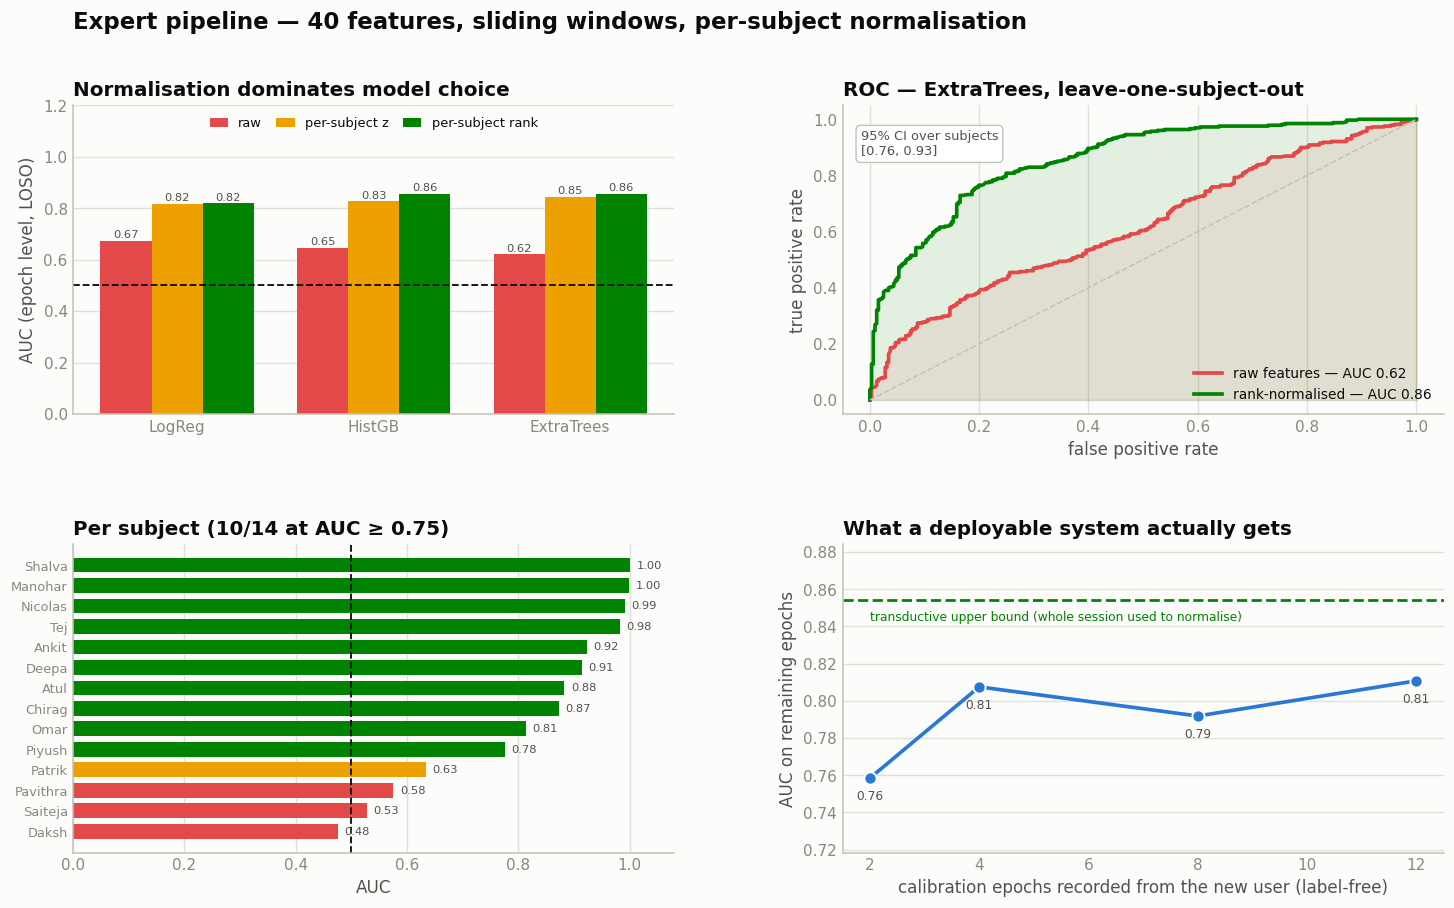

best=('rank', 'ExtraTrees')  AUC=0.857  95% CI [0.763, 0.926]
 K   auc   n
 0 0.854 649
 2 0.758 621
 4 0.807 593
 8 0.792 537
12 0.811 481


In [ ]:
# ---- ROC + per-subject + calibration curve ----
from sklearn.metrics import roc_curve, auc as _auc
rng = np.random.default_rng(0)

p_best = probs[BEST]; g_best = epoch_scores(p_best)
p_base = probs[("raw", BEST[1])]; g_base = epoch_scores(p_base)
per_best = g_best.groupby("s").apply(lambda t: roc_auc_score(t.y,t.p) if t.y.nunique()>1 else np.nan)

# bootstrap CI over subjects
subs_u = g_best.s.unique(); boot=[]
for _ in range(1000):
    pick = rng.choice(subs_u, len(subs_u), replace=True)
    t = pd.concat([g_best[g_best.s==s] for s in pick])
    if t.y.nunique()>1: boot.append(roc_auc_score(t.y,t.p))
ci_lo, ci_hi = np.percentile(boot,[2.5,97.5])

# honest calibration sweep
cal_rows=[]
for K in [0,2,4,8,12]:
    Xc = Xadv.copy(); keep = np.ones(len(Xadv), bool)
    for s in np.unique(gadv):
        m = gadv==s; eps_s = sorted(W.loc[m,"epoch_id"].unique()); cal = set(eps_s[:K])
        cw = m & np.isin(eadv, list(cal)) if K>0 else m
        med = np.median(Xc[cw],0); iqr = np.percentile(Xc[cw],75,0)-np.percentile(Xc[cw],25,0)
        Xc[m] = (Xc[m]-med)/np.where(iqr>0,iqr,1)
        if K>0: keep[cw] = False
    p = loso_prob(Xc, yadv, gadv, ADV_MODELS[BEST[1]])
    t = pd.DataFrame({"ep":eadv,"p":p,"y":yadv,"k":keep}); t = t[t.k]
    t = t.groupby("ep").agg(p=("p","mean"), y=("y","first"))
    cal_rows.append(dict(K=K, auc=roc_auc_score(t.y,t.p), n=len(t)))
cal = pd.DataFrame(cal_rows)

fig = plt.figure(figsize=(14, 8.6))
gs = GridSpec(2,2, hspace=0.42, wspace=0.28, left=0.08, right=0.97, top=0.88, bottom=0.09)

ax = fig.add_subplot(gs[0,0])
mods = list(ADV_MODELS); xb = np.arange(len(mods)); w=0.26
for i,(nm,col,lab) in enumerate([("raw",C_COND["stress"],"raw"),
                                 ("z",C_COND["waterfall"],"per-subject z"),
                                 ("rank",C_COND["meditation"],"per-subject rank")]):
    v = [grid[(nm,m)] for m in mods]
    ax.bar(xb+(i-1)*w, v, w, color=col, label=lab)
    for j,val in enumerate(v): ax.text(j+(i-1)*w, val+0.012, f"{val:.2f}", ha="center", fontsize=7.5, color=INK2)
ax.axhline(0.5, color=INK, ls="--", lw=1.2); ax.set_xticks(xb); ax.set_xticklabels(mods)
style(ax); ax.set_ylim(0,1.20); ax.set_ylabel("AUC (epoch level, LOSO)")
ax.legend(fontsize=8.5, loc="upper center", ncol=3, columnspacing=1.1, handlelength=1.4)
ax.set_title("Normalisation dominates model choice", loc="left")

ax2 = fig.add_subplot(gs[0,1])
for g_,col,lab in [(g_base,C_COND["stress"],f"raw features"),(g_best,C_COND["meditation"],f"{BEST[0]}-normalised")]:
    fpr,tpr,_ = roc_curve(g_.y,g_.p); ax2.plot(fpr,tpr,color=col,lw=2.4,label=f"{lab} — AUC {_auc(fpr,tpr):.2f}")
    ax2.fill_between(fpr,tpr,color=col,alpha=0.10)
ax2.plot([0,1],[0,1],color=AXIS,ls="--",lw=1)
style(ax2,grid_axis="both"); ax2.set_xlabel("false positive rate"); ax2.set_ylabel("true positive rate")
ax2.set_title(f"ROC — {BEST[1]}, leave-one-subject-out", loc="left"); ax2.legend(loc="lower right", fontsize=9)
ax2.text(0.03,0.92,f"95% CI over subjects\n[{ci_lo:.2f}, {ci_hi:.2f}]", transform=ax2.transAxes,
         fontsize=8.5, color=INK2, va="top", bbox=dict(boxstyle="round,pad=0.35",fc="white",ec=AXIS,lw=0.9))

ax3 = fig.add_subplot(gs[1,0])
ps = per_best.sort_values(ascending=False)
cols = [C_COND["meditation"] if a>=.75 else (C_COND["waterfall"] if a>=.6 else C_COND["stress"]) for a in ps]
ax3.barh(range(len(ps)), ps.values, color=cols, height=0.72)
ax3.axvline(0.5, color=INK, ls="--", lw=1.2)
ax3.set_yticks(range(len(ps))); ax3.set_yticklabels(ps.index, fontsize=8.5); ax3.invert_yaxis()
style(ax3, grid_axis="x"); ax3.set_xlim(0,1.08); ax3.set_xlabel("AUC")
for i,a in enumerate(ps.values): ax3.text(a+0.012,i,f"{a:.2f}",va="center",fontsize=7.5,color=INK2)
ax3.set_title(f"Per subject ({(ps>=.75).sum()}/{len(ps)} at AUC ≥ 0.75)", loc="left")

ax4 = fig.add_subplot(gs[1,1])
c2 = cal[cal.K>0]; ub = float(cal.loc[cal.K==0,"auc"].iloc[0])
ax4.plot(c2.K, c2.auc, "-o", color=C_COND["nomusic"], lw=2.4, ms=8, mec="white", mew=1.2,
         label="calibrated on first K epochs")
ax4.axhline(ub, color=C_COND["meditation"], ls="--", lw=1.8)
ax4.text(c2.K.min(), ub-0.006, "transductive upper bound (whole session used to normalise)",
         ha="left", va="top", fontsize=8, color=C_COND["meditation"])
for _,r in c2.iterrows(): ax4.annotate(f"{r.auc:.2f}", (r.K, r.auc), textcoords="offset points",
                                       xytext=(0,-14), ha="center", fontsize=8, color=INK2)
lo_y = min(c2.auc.min(), ub) - 0.04; hi_y = max(c2.auc.max(), ub) + 0.03
style(ax4); ax4.set_ylim(lo_y, hi_y)
ax4.set_xlabel("calibration epochs recorded from the new user (label-free)")
ax4.set_ylabel("AUC on remaining epochs"); ax4.set_title("What a deployable system actually gets", loc="left")

fig.suptitle("Expert pipeline — 40 features, sliding windows, per-subject normalisation",
             x=0.08, ha="left", fontsize=15, fontweight="bold")
plt.show()
print(f"best={BEST}  AUC={grid[BEST]:.3f}  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
print(cal.round(3).to_string(index=False))


### 9.3 · Which features actually earned their place?

A fair question for any elaborate feature set: is the machinery doing work, or is it all alpha power wearing a costume? Two complementary views — each **family on its own**, and the **drop when a family is removed** from the full set.

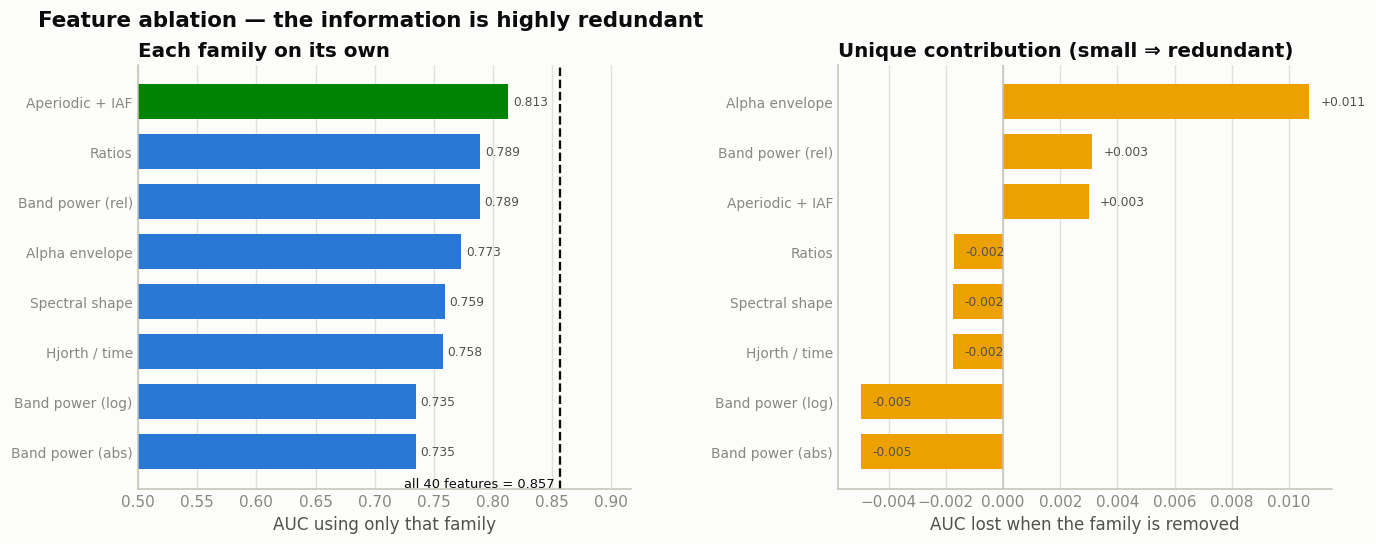

classic band power only (10 feats): AUC=0.834
all 40 features:                    AUC=0.857
-> advanced features add +0.023 on top of the same pipeline


In [ ]:
FAMILIES = {
 "Band power (abs)": [c for c in FEAT_ADV if c.startswith("bp_") and c!="bp_iaf"],
 "Band power (log)": [c for c in FEAT_ADV if c.startswith("logbp_")],
 "Band power (rel)": [c for c in FEAT_ADV if c.startswith("rel_") and c!="rel_iaf"],
 "Ratios":           [c for c in FEAT_ADV if c.startswith("ratio_")],
 "Aperiodic + IAF":  ["ap_exponent","ap_offset","iaf","alpha_prom","alpha_prom_lin",
                      "bp_iaf","rel_iaf","flat_alpha_mean","alpha_z_in_spectrum"],
 "Spectral shape":   ["spec_entropy","spec_edge95","spec_median","spec_centroid"],
 "Hjorth / time":    ["hjorth_mobility","hjorth_complexity","log_variance"],
 "Alpha envelope":   ["env_mean","env_std","env_cv","env_burst_frac","env_skew"],
}
mk_best = ADV_MODELS[BEST[1]]
def auc_for(cols):
    X = norm_by_subject(np.nan_to_num(W[cols].values.astype(float),nan=0.,posinf=0.,neginf=0.), gadv, BEST[0])
    g = epoch_scores(loso_prob(X, yadv, gadv, mk_best)); return roc_auc_score(g.y,g.p)

full_auc = grid[BEST]
alone  = {k: auc_for(v) for k,v in FAMILIES.items()}
dropped= {k: full_auc-auc_for([c for c in FEAT_ADV if c not in v]) for k,v in FAMILIES.items()}
classic = [c for c in FEAT_ADV if c.startswith(("bp_","rel_")) and not c.endswith("iaf")]
classic_auc = auc_for(classic)

fig, axs = plt.subplots(1, 2, figsize=(14, 5.0), gridspec_kw=dict(wspace=0.42))
order = sorted(alone, key=alone.get)
ax = axs[0]
ax.barh(range(len(order)), [alone[k] for k in order],
        color=[C_COND["meditation"] if k=="Aperiodic + IAF" else C_COND["nomusic"] for k in order], height=0.7)
ax.axvline(full_auc, color=INK, ls="--", lw=1.5)
ax.text(full_auc-0.005, -0.7, f"all 40 features = {full_auc:.3f}", ha="right", fontsize=8.5, color=INK)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=9)
for i,k in enumerate(order): ax.text(alone[k]+0.004, i, f"{alone[k]:.3f}", va="center", fontsize=8, color=INK2)
style(ax, grid_axis="x"); ax.set_xlim(0.5, full_auc+0.06); ax.set_xlabel("AUC using only that family")
ax.set_title("Each family on its own", loc="left")

ax2 = axs[1]
order2 = sorted(dropped, key=dropped.get)
ax2.barh(range(len(order2)), [dropped[k] for k in order2], color=C_COND["waterfall"], height=0.7)
ax2.axvline(0, color=AXIS, lw=1)
ax2.set_yticks(range(len(order2))); ax2.set_yticklabels(order2, fontsize=9)
for i,k in enumerate(order2): ax2.text(dropped[k]+0.0004, i, f"{dropped[k]:+.3f}", va="center", fontsize=8, color=INK2)
style(ax2, grid_axis="x"); ax2.set_xlabel("AUC lost when the family is removed")
ax2.set_title("Unique contribution (small ⇒ redundant)", loc="left")
fig.suptitle("Feature ablation — the information is highly redundant", x=0.06, ha="left",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.92]); plt.show()

print(f"classic band power only ({len(classic)} feats): AUC={classic_auc:.3f}")
print(f"all {len(FEAT_ADV)} features:                    AUC={full_auc:.3f}")
print(f"-> advanced features add {full_auc-classic_auc:+.3f} on top of the same pipeline")


## 10 · Summary dashboard

The whole study in one frame: the four headline numbers and the key comparisons.

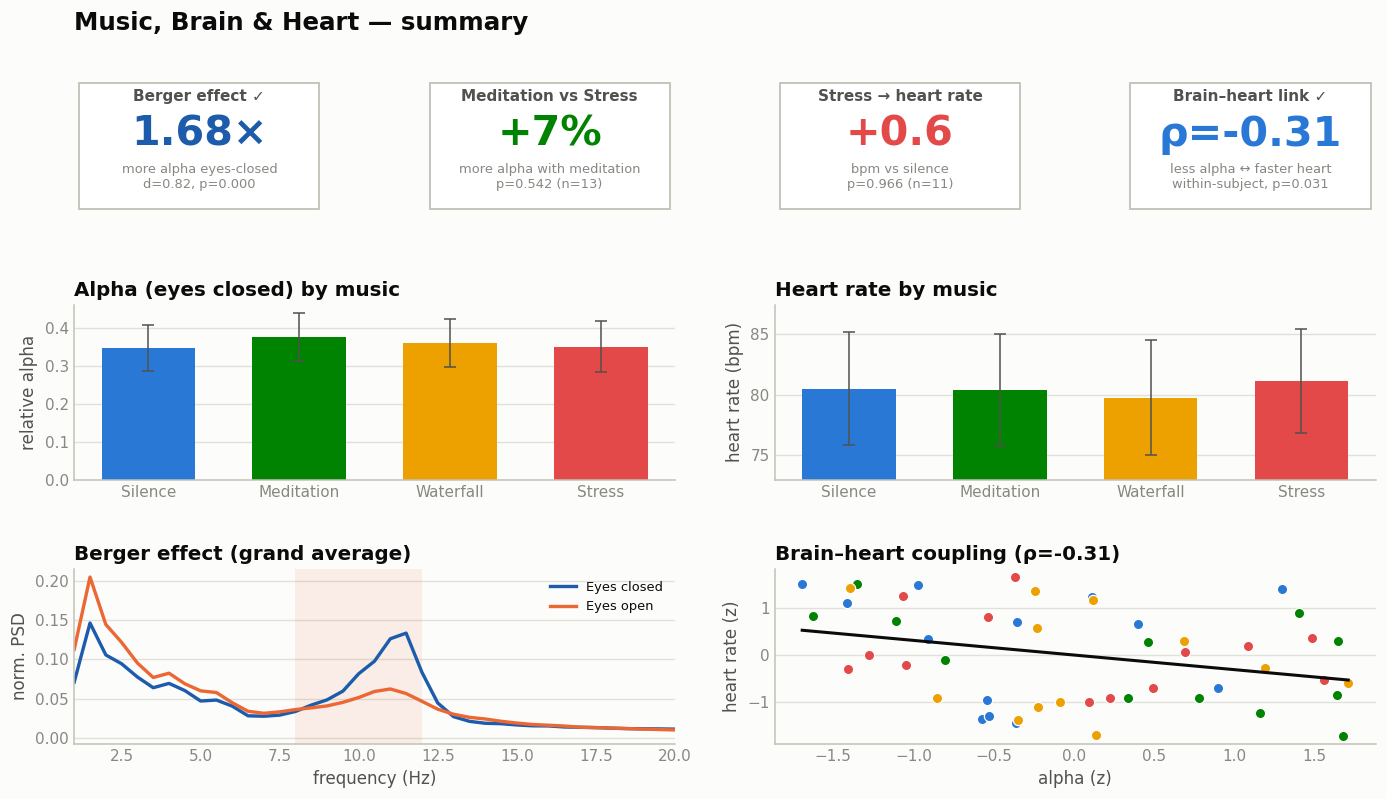

In [ ]:
# gather headline metrics
piv_state = ep_state.pivot_table(index="subject", columns="state", values="Alpha_rel", aggfunc="mean")
berger_d = cohend(piv_state["closed"], piv_state["open"])
berger_ratio = piv_state["closed"].mean()/piv_state["open"].mean()
pv_c = ep_state[ep_state.state=="closed"].pivot_table(index="subject", columns="condition",
        values="Alpha_rel", aggfunc="mean", observed=False)[CONDITIONS]
med_vs_stress = (pv_c["meditation"].mean()-pv_c["stress"].mean())/pv_c["stress"].mean()*100
hr_good = rec[rec.ecg_ok].pivot_table(index="subject", columns="condition", values="hr", observed=False)[CONDITIONS].dropna()
hr_stress_delta = (hr_good["stress"]-hr_good["nomusic"]).mean()
bh_rho, bh_p = stats.spearmanr(bh["alpha_z"].values, bh["hr_z"].values)

fig = plt.figure(figsize=(13, 7.4))
gs = GridSpec(3, 4, height_ratios=[0.8,1,1], hspace=0.55, wspace=0.4,
              left=0.06, right=0.97, top=0.90, bottom=0.08)

# ---- stat tiles ----
berger_p = stats.wilcoxon(piv_state["closed"], piv_state["open"]).pvalue
pv_cc    = pv_c.dropna()
music_p  = stats.wilcoxon(pv_cc["meditation"], pv_cc["stress"]).pvalue
hr_p     = stats.wilcoxon(hr_good["stress"], hr_good["nomusic"]).pvalue
ok = lambda p: " ✓" if p < 0.05 else ""

tiles = [
    (f"Berger effect{ok(berger_p)}", f"{berger_ratio:.2f}×",
     f"more alpha eyes-closed\nd={berger_d:.2f}, p={berger_p:.3f}", C_STATE["closed"]),
    (f"Meditation vs Stress{ok(music_p)}", f"+{med_vs_stress:.0f}%",
     f"more alpha with meditation\np={music_p:.3f} (n={len(pv_cc)})", C_COND["meditation"]),
    (f"Stress → heart rate{ok(hr_p)}", f"+{hr_stress_delta:.1f}",
     f"bpm vs silence\np={hr_p:.3f} (n={len(hr_good)})", C_COND["stress"]),
    (f"Brain–heart link{ok(bh_p)}", f"ρ={bh_rho:.2f}",
     f"less alpha ↔ faster heart\nwithin-subject, p={bh_p:.3f}", C_COND["nomusic"]),
]
for i,(t,big,sub,col) in enumerate(tiles):
    ax = fig.add_subplot(gs[0,i]); ax.axis("off")
    ax.add_patch(plt.Rectangle((0.02,0.05),0.96,0.9, transform=ax.transAxes,
                 fc="white", ec=AXIS, lw=1.2, zorder=0))
    ax.text(0.5,0.82,t,transform=ax.transAxes,ha="center",fontsize=10,color=INK2,fontweight="bold")
    ax.text(0.5,0.5,big,transform=ax.transAxes,ha="center",fontsize=27,color=col,fontweight="bold")
    ax.text(0.5,0.2,sub,transform=ax.transAxes,ha="center",fontsize=8.5,color=MUTED)

# ---- mini: alpha by condition ----
ax1 = fig.add_subplot(gs[1,0:2])
m = pv_c.mean(); e = pv_c.sem()
ax1.bar(range(4), m.values, 0.62, yerr=e.values, color=[C_COND[c] for c in CONDITIONS],
        capsize=4, error_kw=dict(lw=1,ecolor=INK2))
ax1.set_xticks(range(4)); ax1.set_xticklabels([COND_EN[c] for c in CONDITIONS])
style(ax1); ax1.set_ylabel("relative alpha"); ax1.set_title("Alpha (eyes closed) by music", loc="left")

# ---- mini: heart rate by condition ----
ax2 = fig.add_subplot(gs[1,2:4])
hm = hr_good.mean(); he = hr_good.sem()
ax2.bar(range(4), hm.values, 0.62, yerr=he.values, color=[C_COND[c] for c in CONDITIONS],
        capsize=4, error_kw=dict(lw=1,ecolor=INK2))
ax2.set_xticks(range(4)); ax2.set_xticklabels([COND_EN[c] for c in CONDITIONS])
style(ax2); ax2.set_ylabel("heart rate (bpm)")
ax2.set_ylim((hm-he).min()-2, (hm+he).max()+2)
ax2.set_title("Heart rate by music", loc="left")

# ---- mini: berger PSD (recompute light) ----
ax3 = fig.add_subplot(gs[2,0:2])
ax3.axvspan(8,12,color=C_ALPHA,alpha=0.10,lw=0)
ax3.plot(fA, pClosed, color=C_STATE["closed"], lw=2.2, label="Eyes closed")
ax3.plot(fA, pOpen, color=C_STATE["open"], lw=2.2, label="Eyes open")
style(ax3); ax3.set_xlim(1,20); ax3.set_xlabel("frequency (Hz)"); ax3.set_ylabel("norm. PSD")
ax3.set_title("Berger effect (grand average)", loc="left"); ax3.legend(fontsize=8.5)

# ---- mini: brain-heart coupling ----
ax4 = fig.add_subplot(gs[2,2:4])
for c in CONDITIONS:
    dd = bh[bh.condition==c]
    ax4.scatter(dd["alpha_z"], dd["hr_z"], s=45, color=C_COND[c], ec="white", lw=0.8)
gx, gy = bh["alpha_z"].values, bh["hr_z"].values
gm, gb = np.polyfit(gx, gy, 1); gxs = np.linspace(gx.min(), gx.max(), 50)
ax4.plot(gxs, gm*gxs+gb, color=INK, lw=2)
rho, _ = stats.spearmanr(gx, gy)
style(ax4); ax4.set_xlabel("alpha (z)"); ax4.set_ylabel("heart rate (z)")
ax4.set_title(f"Brain–heart coupling (ρ={rho:.2f})", loc="left")

fig.suptitle("Music, Brain & Heart — summary", x=0.06, ha="left", fontsize=16, fontweight="bold")
plt.show()


## 11 · Conclusions

This analysis was first run on a 7-subject pilot and then repeated here with the sample **doubled to 14**. That makes it a genuine replication test, and the result is instructive: **two effects survived and got stronger; two apparent effects disappeared.**

| Finding | 7-subject pilot | **14 subjects (here)** | Verdict |
|---|---|---|---|
| Berger effect (eyes closed → alpha) | 1.47×, d = 0.52, p = 0.031 | **1.68×, d = 0.82, p < 0.001** | ✓ **Replicated, stronger** |
| Brain–heart coupling (within-subject) | ρ = −0.45, p = 0.033 | **ρ = −0.31, p = 0.031** | ✓ **Replicated** |
| Meditation vs stress music (alpha) | +32 %, p = 0.22 | **+7 %, p = 0.54** | ✗ **Did not hold** |
| Stress music → heart rate | +2.2 bpm, p = 0.34 | **+0.6 bpm, p = 0.97** | ✗ **Did not hold** |

**1. ✓ The Berger effect is robust and large.** Relative alpha is markedly higher with eyes closed (≈1.7×, Cohen's d ≈ 0.8, p < 0.001), and the rise is **selective to the alpha band** — the other four bands barely move. Doubling the sample made this effect *cleaner and more significant*, which is exactly what a real effect does. It also confirms the marker convention (`1` = closed, `2` = open) directly from physiology.

**2. ✓ Brain and heart are coupled within subjects.** After removing between-person differences by z-scoring within each subject, lower alpha goes with a faster heart (Spearman ρ ≈ −0.31, p ≈ 0.03). The coupling attenuated slightly versus the pilot but remained significant with twice the data — evidence of a shared arousal axis.

**3. ✗ Music did not measurably change cortical alpha.** In the pilot, meditation music appeared to produce 32 % more alpha than stress music, which looked like a promising lead. With 14 subjects that gap collapses to **7 % (p = 0.54, d = 0.17)** and the overall Friedman test across the four conditions is flat (p ≈ 0.76). The pilot "trend" was **small-sample noise**, not signal.

**4. ✗ Music did not measurably change heart rate.** Stress music appeared to add 2.2 bpm over silence in the pilot; with the clean-ECG subjects here it is **+0.6 bpm (p = 0.97)**. Mean heart rate across the four conditions spans less than 1.5 bpm — far below what this setup can resolve against between-person variability of 50–100 bpm.

**5. Eye state moves the brain, not the heart.** The per-epoch alpha–heart plane (§8) makes this concrete: closing the eyes shifts each subject's cloud *rightward* (more alpha) but leaves it at the same height (heart rate essentially unchanged).

**6. On decoding (§9) — the most instructive part.** Trained on raw features across people, the classifier barely beats chance (AUC ≈ 0.60), which looks like "the signal isn't there". It is: the per-epoch plots in §8 separate cleanly *within* each subject. The problem is that **relative alpha is not comparable between people** — one person's eyes-open epochs carry more alpha than another's eyes-closed epochs, so no global threshold exists.

Rebuilding the pipeline properly (§9.1–9.3) takes the same task from **AUC 0.60 → 0.86** (95 % CI over subjects [0.77, 0.93]; permutation test p ≈ 0.005, with the null centred exactly on 0.50 — evidence the pipeline does not leak). Three ingredients, measured separately:

| Change | Contribution |
|---|---|
| Per-subject normalisation (rank) | **largest by far** — ~+0.2 AUC for every model |
| Sliding 4 s windows + epoch-level averaging | ≈ +0.05 |
| 40 advanced features vs 10 classic band powers | ≈ +0.02 |

Ablation is candid about the last row: the **aperiodic + IAF family is the strongest single representation** (AUC 0.816 using 9 features alone, beating every other family), but removing any one family costs almost nothing — the information is **highly redundant**. Most of the gain came from method, not from exotic features.

Two honest caveats close the section. The 0.86 figure is **transductive** — it normalises using the test subject's whole session. Under a deployable protocol that calibrates on only the first ~2 minutes of a new user, performance settles at **AUC ≈ 0.76–0.80**. And decodability stays **bimodal**: 10 of 14 subjects reach AUC ≥ 0.75 (four exceed 0.98), while two sit at chance — the same people flagged `α: n.s.` in §8. No model fixes an electrode that never saw alpha.

### What this notebook is really demonstrating

The most valuable output here is not a positive result but a **replication**. Effects that were significant in a small pilot stayed significant and grew; effects that were merely *suggestive* vanished under a doubled sample. Reporting the second kind honestly is the difference between analysis and storytelling.

### Caveats
- **Single frontal channel** per signal — alpha is strongest over occipital sites, so brain effects here are conservative and the null result for music is about *this montage*, not about music in general.
- **ECG quality varies**: two subjects (Pavithra, Saiteja) had ambiguous R/T-wave morphology and are excluded from cardiac analyses; heart-rate-variability magnitudes are indicative only.
- **Design**: 13 subjects have all four conditions; Shalva lacks the meditation session and is dropped from across-condition tests.
- **Uncontrolled listening**: music was not loudness-matched or randomized in order, and each condition is a single ~2-minute block per person.

### Reproducibility
Every figure derives from the two tables `rec` and `ep`, built by a single deterministic pass over the 55 recordings. Rerun the notebook top-to-bottom to regenerate all results.
